# Fairness in Diabetes-Related Classification Across Racial/Ethnic Groups Using IPUMS Health Survey Data

This notebook presents the experimental pipeline for our course project on fairness in healthcare machine learning. Using IPUMS/NHIS survey data, we construct a diabetes-related classification task and evaluate whether predictive models perform differently across racial/ethnic groups.

The notebook includes data cleaning, target and protected-group construction, feature preprocessing, baseline model training, overall performance evaluation, subgroup fairness analysis, and visualization of disparities across groups.

## Note on Project Scope Refinement

Our initial project proposal framed the task as predicting Type 2 diabetes and examining whether genetic factors directly explain ethnic disparities. However, after reviewing the available IPUMS/NHIS survey variables and implementing the first round of experiments, I concluded that the scope of the project is better framed as **fairness in diabetes-related classification across racial/ethnic groups**.

This refinement is motivated by the structure of the dataset itself. The IPUMS/NHIS data used here are survey-based health data rather than genetic or causal data. The available variables primarily describe demographic characteristics, race/ethnicity, education, healthcare access, affordability barriers, and diabetes-related health status. These variables support a supervised classification task and subgroup-based fairness evaluation, but they do not support direct inference about genetic mechanisms or causal pathways explaining disparity.

At the same time, the dataset is well suited for fairness-oriented analysis. It contains:
- diabetes-related variables that can be used to define a classification target,
- race/ethnicity-related variables that can be used to define protected groups,
- social and healthcare-access variables that may contribute to predictive disparities, and
- a large multi-year survey sample that enables comparison across demographic groups.

For these reasons, this notebook focuses on whether machine learning models exhibit differences in predictive performance and error rates across racial/ethnic groups, rather than attempting to identify direct genetic explanations for those disparities.

Specifically, this notebook:
- constructs a diabetes-related classification task from survey variables,
- uses race/ethnicity-related variables as protected group indicators,
- compares baseline predictive models, and
- evaluates fairness using group-based performance metrics such as recall, false positive rate, false negative rate, and predicted positive rate.

This reframed scope better matches the data, methods, and fairness objectives of the course project.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, brier_score_loss,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Dataset Overview

This project uses a sample extracted from IPUMS Health Surveys / NHIS data. The dataset contains demographic, education, healthcare access, and diabetes-related variables collected across multiple survey years.

At this stage, the goal is to load the data, inspect its structure, and identify the variables that may be used for:
- the classification target,
- protected group definitions, and
- candidate predictive features.

### Data Loading

In [2]:
project_dir = Path(".")
data_path = project_dir / "ipums_v2.csv"

df = pd.read_csv(data_path)

print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

print("Survey years in sample:", sorted(df["YEAR"].dropna().unique().tolist()))
df

Shape: (188419, 63)

Columns:
['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'REGION', 'URBRRL', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'LONGWEIGHT', 'PARTWEIGHT', 'ASTATFLG', 'CSTATFLG', 'AGE', 'SEX', 'RACENEW', 'HISPETH', 'HISPRACE', 'HISPYN', 'USBORN', 'CITIZEN', 'NOWAF', 'ARMFEV', 'EDUC', 'SPOUSEDUC', 'SCHOOLNOW', 'EMPSTAT', 'HOURSWRK', 'PAIDSICK', 'EMPHI', 'SPOUSWRK', 'GOTWELF', 'WCHSSISSDI', 'WHYSSISSDI', 'GOTSS', 'POVERTY', 'HEALTH', 'HEIGHT', 'WEIGHT', 'PREGNANTNOW', 'USUALPL', 'TYPPLSICK', 'DELAYCOST', 'YBARCARE', 'YBARDENTAL', 'YBARMEDS', 'YBARMENTAL', 'CHOLHIGHYR', 'DIABETICEV', 'HEARTATTEV', 'HYPERTENYR', 'STROKEV', 'DIABETICAGE', 'DIABTYPE', 'DIAPRE', 'DIADIAGPREG', 'CHOLMEDNOW', 'HYPMEDNOW', 'SMOKESTATUS2', 'ECIGEV', 'PA18AERSTR']
Survey years in sample: [2020, 2021, 2022, 2023, 2024]


,YEAR,SERIAL,STRATA,PSU,NHISHID,REGION,URBRRL,PERNUM,NHISPID,HHX,...,STROKEV,DIABETICAGE,DIABTYPE,DIAPRE,DIADIAGPREG,CHOLMEDNOW,HYPMEDNOW,SMOKESTATUS2,ECIGEV,PA18AERSTR
0,2020,1,150,25,0002020H000002,3,2,1,0002020H00000210,H000002,...,1,96,0,1,1,0,0,12,1,1.0
1,2020,2,111,10,0002020H000003,4,3,1,0002020H00000310,H000003,...,1,96,0,1,0,2,0,30,1,3.0
2,2020,3,133,3,0002020H000004,2,2,1,0002020H00000410,H000004,...,1,96,0,1,1,2,0,30,1,2.0
3,2020,4,139,45,0002020H000007,3,3,1,0002020H00000710,H000007,...,1,53,3,2,0,2,2,30,1,1.0
4,2020,5,130,21,0002020H000009,3,1,1,0002020H00000910,H000009,...,1,96,0,2,1,0,2,90,8,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188414,2024,33913,135,25,0002024H080023,3,2,1,0002024H08002310,H080023,...,1,96,0,2,0,2,0,30,1,3.0
188415,2024,33914,116,19,0002024H080026,1,4,1,0002024H08002610,H080026,...,1,96,0,1,1,0,0,30,1,1.0
188416,2024,33915,119,6,0002024H080027,4,1,1,0002024H08002710,H080027,...,1,96,0,1,0,0,0,30,1,3.0
188417,2024,33916,107,36,0002024H080034,2,2,1,0002024H08003410,H080034,...,1,96,0,1,0,0,0,30,1,1.0


### Data Inspection

In [3]:
selected_features = [
    "YEAR", "AGE", "SEX", "USBORN", "CITIZEN", "EDUC",
    "USUALPL", "REGION", "EMPSTAT", "DELAYCOST",
    "YBARCARE", "YBARMEDS", "HEALTH", "POVERTY", "HEIGHT", "WEIGHT"
]

# RACENEW is used as the primary protected attribute.
# HISPETH was considered but not used because RACENEW already captures
# the major racial/ethnic groupings. Including HISPETH would create
# overlapping categories that complicate the fairness analysis.
protected_group_candidates = ["RACENEW"]

diabetes_variables = ["DIABTYPE", "DIAPRE", "DIADIAGPREG", "DIABETICEV", "DIABETICAGE"]

missing_cols = [col for col in selected_features + protected_group_candidates + diabetes_variables if col not in df.columns]
print("Missing columns from analysis-related variables:", missing_cols)

print("\nDataFrame info:")
df.info()

missing_summary = (
    df[selected_features + protected_group_candidates + diabetes_variables]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in analysis-related variables:")
print(missing_summary)

Missing columns from analysis-related variables: []

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188419 entries, 0 to 188418
Data columns (total 63 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   YEAR          188419 non-null  int64  
 1   SERIAL        188419 non-null  int64  
 2   STRATA        188419 non-null  int64  
 3   PSU           188419 non-null  int64  
 4   NHISHID       188419 non-null  object 
 5   REGION        188419 non-null  int64  
 6   URBRRL        188419 non-null  int64  
 7   PERNUM        188419 non-null  int64  
 8   NHISPID       188419 non-null  object 
 9   HHX           188419 non-null  object 
 10  SAMPWEIGHT    188419 non-null  float64
 11  LONGWEIGHT    37358 non-null   float64
 12  PARTWEIGHT    37358 non-null   float64
 13  ASTATFLG      188419 non-null  int64  
 14  CSTATFLG      188419 non-null  int64  
 15  AGE           188419 non-null  int64  
 16  SEX           188419 no

In [4]:
for col in ["DIABTYPE", "RACENEW"]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False).sort_index())
    
    print(f"\nUnique values in {col}:")
    print(sorted(df[col].dropna().unique()))


DIABTYPE value counts:
DIABTYPE
0    171980
1      1374
2     13833
3       360
7        13
9       859
Name: count, dtype: int64

Unique values in DIABTYPE:
[0, 1, 2, 3, 7, 9]

RACENEW value counts:
RACENEW
100    137614
200     20644
300      1773
400     11469
510      4194
542      1865
997       111
998     10587
999       162
Name: count, dtype: int64

Unique values in RACENEW:
[100, 200, 300, 400, 510, 542, 997, 998, 999]


In [5]:
special_codes = {
    7, 8, 9,
    97, 98, 99,
    997, 998, 999,
    9997, 9998, 9999
}

feature_quality_summary = pd.DataFrame({
    "feature": selected_features,
    "missing_count": [df[col].isna().sum() for col in selected_features],
    "missing_rate": [round(df[col].isna().mean(), 4) for col in selected_features],
    "special_code_count": [int(df[col].isin(special_codes).sum()) for col in selected_features],
    "special_code_rate": [round(float(df[col].isin(special_codes).mean()), 4) for col in selected_features],
    "n_unique": [df[col].nunique(dropna=False) for col in selected_features]
}).sort_values(by="special_code_rate", ascending=False)

feature_quality_summary

,feature,missing_count,missing_rate,special_code_count,special_code_rate,n_unique
1,AGE,0,0.0,6016,0.0319,88
4,CITIZEN,0,0.0,6010,0.0319,5
3,USBORN,0,0.0,5753,0.0305,5
8,EMPSTAT,0,0.0,5602,0.0297,4
15,WEIGHT,0,0.0,3042,0.0161,255
11,YBARMEDS,0,0.0,1544,0.0082,5
10,YBARCARE,0,0.0,1302,0.0069,5
9,DELAYCOST,0,0.0,1272,0.0068,5
6,USUALPL,0,0.0,1176,0.0062,6
5,EDUC,0,0.0,741,0.0039,16


In [6]:
high_risk_features = ["CITIZEN", "USBORN", "USUALPL", "EDUC", "DELAYCOST", "HEALTH"]

for col in high_risk_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- CITIZEN ---
CITIZEN
1     10373
2    172036
7       302
8      5637
9        71
Name: count, dtype: int64

--- USBORN ---
USBORN
10     25189
20    157477
97       123
98      5614
99        16
Name: count, dtype: int64

--- USUALPL ---
USUALPL
1     13928
2    170068
3      3247
7        58
8      1026
9        92
Name: count, dtype: int64

--- EDUC ---
EDUC
0      37567
102       59
103    10092
116     2403
201    34203
202     3439
301    22573
302     5904
303    13711
400    34955
510    16944
520     4592
521      518
522      718
997      225
999      516
Name: count, dtype: int64

--- DELAYCOST ---
DELAYCOST
1    176362
2     10785
7        41
8      1188
9        43
Name: count, dtype: int64

--- HEALTH ---
HEALTH
1    56276
2    59737
3    48162
4    18641
5     5519
7       46
9       38
Name: count, dtype: int64


In [7]:
output_dir = Path("outputs_2")
output_dir.mkdir(exist_ok=True)

df["DIABTYPE"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "DIABTYPE_value", "DIABTYPE": "count"}
).to_csv(output_dir / "diabtype_value_counts.csv", index=False)

df["RACENEW"].value_counts(dropna=False).sort_index().reset_index().rename(
    columns={"index": "RACENEW_value", "RACENEW": "count"}
).to_csv(output_dir / "racenew_value_counts.csv", index=False)

feature_quality_summary.to_csv(output_dir / "feature_quality_summary.csv", index=False)

print("Saved summary files.")

Saved summary files.


### Target Definition Audit

The final task in this notebook is framed as diabetes-related binary classification. The target is constructed from DIABTYPE, where DIABTYPE=2 (Type 2 diabetes) is labeled as positive. The protected groups are based on RACENEW after regrouping into major racial/ethnic categories.

In [8]:
target_audit_cols = ["DIAPRE", "DIABTYPE", "DIADIAGPREG"]

for col in target_audit_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False).sort_index())

target_definition_summary = pd.DataFrame({
    "variable": target_audit_cols,
    "non_null_count": [df[c].notna().sum() for c in target_audit_cols],
    "non_null_rate": [round(df[c].notna().mean(), 4) for c in target_audit_cols],
    "n_unique": [df[c].nunique(dropna=False) for c in target_audit_cols]
})

display(target_definition_summary)


=== DIAPRE ===
DIAPRE
1    162570
2     25563
7       126
9       160
Name: count, dtype: int64

=== DIABTYPE ===
DIABTYPE
0    171980
1      1374
2     13833
3       360
7        13
9       859
Name: count, dtype: int64

=== DIADIAGPREG ===
DIADIAGPREG
0    106500
1     76987
2      4715
7        36
8        51
9       130
Name: count, dtype: int64


,variable,non_null_count,non_null_rate,n_unique
0,DIAPRE,188419,1.0,4
1,DIABTYPE,188419,1.0,6
2,DIADIAGPREG,188419,1.0,6


We inspected several diabetes-related variables (DIAPRE, DIABTYPE, and DIADIAGPREG) to determine which variable was most suitable for defining the prediction target. Based on this audit, we used DIABTYPE to construct a binary Type 2 diabetes label.

## Data Cleaning

In [9]:
df_model = df.copy()

unknown_diabtype = {7, 8, 9}
n_before = len(df_model)
df_model = df_model[~df_model["DIABTYPE"].isin(unknown_diabtype)].copy()
print(f"Dropped {n_before - len(df_model)} rows with unknown DIABTYPE (7/8/9)")

# Construct binary target: Type 2 = positive, all other substantive codes = negative
df_model["diabetes_label"] = df_model["DIABTYPE"].map({0: 0, 1: 0, 2: 1, 3: 0})

# DIADIAGPREG=2 means diabetes was first diagnosed during pregnancy (gestational)
# These are clinically distinct from chronic Type 2 and should not be counted as positive.
n_before_preg = len(df_model)
gestational_mask = (df_model["diabetes_label"] == 1) & (df_model["DIADIAGPREG"] == 2)
n_gestational = gestational_mask.sum()
df_model.loc[gestational_mask, "diabetes_label"] = 0
print(f"Reclassified {n_gestational} gestational-diabetes cases (DIADIAGPREG=2) as negative")

# Retain main race categories
valid_race_codes = [100, 200, 300, 400, 510, 542]
df_model = df_model[df_model["RACENEW"].isin(valid_race_codes)].copy()

race_map = {100: "White", 200: "Black", 300: "AIAN", 400: "Asian", 510: "Other/Multi", 542: "Other/Multi"}
df_model["race_group"] = df_model["RACENEW"].map(race_map)

# HISPETH=10 means non-Hispanic; codes 20+ indicate Hispanic origin.
# HISPETH=0 is NIU (Not In Universe) — should be NaN, not non-Hispanic.
# HISPETH=97/98/99 are unknown/refused/not-ascertained — should be NaN, not Hispanic.
hispeth_unknown = {0, 97, 98, 99}
df_model["hispanic"] = df_model["HISPETH"].apply(
    lambda x: np.nan if x in hispeth_unknown else (1 if x >= 20 else 0)
)
print(f"\nHispanic indicator distribution (NaN = unknown/NIU):")
print(df_model["hispanic"].value_counts(dropna=False))

# ===== FEATURE SETS =====

# Categorical features (will be one-hot encoded)
categorical_features = [
    "USBORN", "CITIZEN", "EDUC", "USUALPL",
    "REGION", "EMPSTAT", "DELAYCOST", "YBARCARE", "YBARMEDS", "HEALTH"
]

# Numerical features (will be standardized)
numerical_features = ["YEAR", "AGE", "POVERTY", "HEIGHT", "WEIGHT"]

model_features = categorical_features + numerical_features

target_col = "diabetes_label"
protected_col = "race_group"

print("\nShape after target/protected-group cleaning:", df_model.shape)
print("\nBinary target distribution:")
print(df_model[target_col].value_counts().sort_index())
print("\nReadable race-group distribution:")
print(df_model["race_group"].value_counts())

Dropped 872 rows with unknown DIABTYPE (7/8/9)
Reclassified 1071 gestational-diabetes cases (DIADIAGPREG=2) as negative

Hispanic indicator distribution (NaN = unknown/NIU):
hispanic
0    156962
1     19811
Name: count, dtype: int64

Shape after target/protected-group cleaning: (176773, 66)

Binary target distribution:
diabetes_label
0    164625
1     12148
Name: count, dtype: int64

Readable race-group distribution:
race_group
White          137093
Black           20490
Asian           11400
Other/Multi      6034
AIAN             1756
Name: count, dtype: int64


In [10]:
# ===== SPECIAL CODE REPLACEMENT =====
# IPUMS uses codes like 7/8/9, 97/98/99, etc. for unknown/refused/not-ascertained.
# These must be replaced with NaN for categorical features ONLY (general case).

special_codes = [7, 8, 9, 97, 98, 99, 997, 998, 999, 9997, 9998, 9999]

# Only apply generic special codes to CATEGORICAL features (not numerical)
for col in categorical_features:
    if col not in ["REGION"]:  # REGION has no special codes
        df_model[col] = df_model[col].replace(special_codes, np.nan)

# IPUMS NHIS HEIGHT: 96=NIU, 97=Refused, 98=Not ascertained, 99=Unknown
height_special = [96, 97, 98, 99]
n_height_special = df_model["HEIGHT"].isin(height_special).sum()
df_model["HEIGHT"] = df_model["HEIGHT"].replace(height_special, np.nan)
print(f"HEIGHT: replaced {n_height_special} special codes (96–99) with NaN")

# IPUMS NHIS WEIGHT: 996=NIU, 997=Refused, 998=Not ascertained, 999=Unknown
weight_special = [996, 997, 998, 999]
n_weight_special = df_model["WEIGHT"].isin(weight_special).sum()
df_model["WEIGHT"] = df_model["WEIGHT"].replace(weight_special, np.nan)
print(f"WEIGHT: replaced {n_weight_special} special codes (996–999) with NaN")

# Replace 0 (NIU = Not In Universe) with NaN for applicable categorical variables
niu_cols = [
    "USBORN", "CITIZEN", "EDUC", "USUALPL", "DELAYCOST",
    "YBARCARE", "YBARMEDS", "HEALTH",
    "EMPSTAT"
]
for col in niu_cols:
    n_niu = (df_model[col] == 0).sum()
    df_model[col] = df_model[col].replace(0, np.nan)
    if n_niu > 0:
        print(f"{col}: replaced {n_niu} NIU (0) values with NaN")

clean_missing_summary = pd.DataFrame({
    "missing_count_after_recoding": df_model[model_features].isna().sum(),
    "missing_rate_after_recoding": df_model[model_features].isna().mean().round(4)
}).sort_values(by="missing_rate_after_recoding", ascending=False)

print("\nMissingness after recoding non-substantive feature values:")
display(clean_missing_summary)

# Only drop rows where target or protected group is missing.
required_non_null = ["diabetes_label", "race_group"]
df_complete = df_model[["diabetes_label", "race_group", "hispanic", "SEX"] + model_features].copy()
df_complete = df_complete.dropna(subset=required_non_null).copy()

print(f"\nRows dropped (missing target or protected group): {len(df_model) - len(df_complete)}")
print("Final modeling dataset shape:", df_complete.shape)
print("\nFeature-level missingness (handled by imputer):")
print(df_complete[model_features].isna().sum().sort_values(ascending=False).head(10))

# ===== DATA QUALITY ASSERTIONS =====
assert df_complete["diabetes_label"].isin([0, 1]).all(), "Target contains values outside {0, 1}"
assert df_complete["race_group"].notna().all(), "race_group contains NaN"
assert df_complete["race_group"].isin(["White", "Black", "Asian", "AIAN", "Other/Multi"]).all(), "Unexpected race_group"
assert len(df_complete) > 100000, f"Too few rows after cleaning: {len(df_complete)}"
max_missing_rate = df_complete[model_features].isna().mean().max()
assert max_missing_rate < 0.5, f"A feature has >50% missing: {max_missing_rate:.2%}"

if "EMPSTAT" in categorical_features:
    empstat_zeros = (df_complete["EMPSTAT"] == 0).sum()
    assert empstat_zeros == 0, f"EMPSTAT still has {empstat_zeros} zero values after NIU replacement!"
    print(f"\n✅ EMPSTAT NIU check passed: 0 zero values remain")

if "EDUC" in categorical_features:
    educ_zeros = (df_complete["EDUC"] == 0).sum()
    assert educ_zeros == 0, f"EDUC still has {educ_zeros} zero values after NIU replacement!"
    print(f"✅ EDUC NIU check passed: 0 zero values remain")

pov_low = df_complete["POVERTY"].isin([7, 8, 9]).sum()
print(f"✅ POVERTY values 7/8/9 preserved: {pov_low} rows (these are real extreme-poverty data)")

height_bad = df_complete["HEIGHT"].isin([96, 97, 98, 99]).sum()
assert height_bad == 0, f"HEIGHT still has {height_bad} special code values!"
print(f"✅ HEIGHT special code check passed: 0 invalid values remain")
height_max = df_complete["HEIGHT"].dropna().max()
print(f"   HEIGHT range after cleaning: {df_complete['HEIGHT'].dropna().min():.0f}–{height_max:.0f} inches")

weight_bad = df_complete["WEIGHT"].isin([996, 997, 998, 999]).sum()
assert weight_bad == 0, f"WEIGHT still has {weight_bad} special code values!"
print(f"✅ WEIGHT special code check passed: 0 invalid values remain")
weight_max = df_complete["WEIGHT"].dropna().max()
print(f"   WEIGHT range after cleaning: {df_complete['WEIGHT'].dropna().min():.0f}–{weight_max:.0f} lbs")

print("✅ All data quality assertions passed.")

HEIGHT: replaced 9903 special codes (96–99) with NaN
WEIGHT: replaced 12588 special codes (996–999) with NaN
EDUC: replaced 34396 NIU (0) values with NaN
EMPSTAT: replaced 34396 NIU (0) values with NaN

Missingness after recoding non-substantive feature values:


,missing_count_after_recoding,missing_rate_after_recoding
EMPSTAT,39521,0.2236
EDUC,35027,0.1981
WEIGHT,12588,0.0712
HEIGHT,9903,0.0560
CITIZEN,5417,0.0306
USBORN,5243,0.0297
YBARMEDS,1415,0.0080
YBARCARE,1199,0.0068
DELAYCOST,1172,0.0066
USUALPL,1089,0.0062



Rows dropped (missing target or protected group): 0
Final modeling dataset shape: (176773, 19)

Feature-level missingness (handled by imputer):
EMPSTAT      39521
EDUC         35027
WEIGHT       12588
HEIGHT        9903
CITIZEN       5417
USBORN        5243
YBARMEDS      1415
YBARCARE      1199
DELAYCOST     1172
USUALPL       1089
dtype: int64

✅ EMPSTAT NIU check passed: 0 zero values remain
✅ EDUC NIU check passed: 0 zero values remain
✅ POVERTY values 7/8/9 preserved: 0 rows (these are real extreme-poverty data)
✅ HEIGHT special code check passed: 0 invalid values remain
   HEIGHT range after cleaning: 0–76 inches
✅ WEIGHT special code check passed: 0 invalid values remain
   WEIGHT range after cleaning: 0–299 lbs
✅ All data quality assertions passed.


In [11]:
n_initial = len(df)
n_after_diabtype = len(df[~df["DIABTYPE"].isin({7, 8, 9})])

valid_race_codes = [100, 200, 300, 400, 510, 542]
tmp_after_race = df[~df["DIABTYPE"].isin({7, 8, 9})].copy()
n_after_race = len(tmp_after_race[tmp_after_race["RACENEW"].isin(valid_race_codes)])
n_final = len(df_complete)

# Note: this step does not change n_remaining (rows are relabelled, not dropped),
# so we report n_positive alongside n_remaining to show the label change.
n_positive_before_gest = (df_model["DIABTYPE"] == 2).sum()  # rough count from DIABTYPE
n_positive_final = df_complete["diabetes_label"].sum()

cleaning_pipeline_summary = pd.DataFrame({
    "step": [
        "Initial raw sample",
        "Exclude unknown DIABTYPE (7/8/9)",
        "Keep valid RACENEW codes",
        f"Reclassify {n_gestational} gestational-diabetes cases as negative",
        "Recode non-substantive feature values as NaN (imputed in pipeline)",
    ],
    "n_remaining": [n_initial, n_after_diabtype, n_after_race, n_after_race, n_final],
    "note": [
        "",
        "",
        "",
        f"n_positive reduced by {n_gestational} (relabel, no rows dropped)",
        f"Final n_positive = {int(n_positive_final)}"
    ]
})
cleaning_pipeline_summary["pct_of_initial"] = (
    cleaning_pipeline_summary["n_remaining"] / n_initial
).round(4)

display(cleaning_pipeline_summary)
cleaning_pipeline_summary.to_csv(output_dir / "cleaning_pipeline_summary.csv", index=False)
print("Saved: outputs_2/cleaning_pipeline_summary.csv")

,step,n_remaining,note,pct_of_initial
0,Initial raw sample,188419,,1.0000
1,Exclude unknown DIABTYPE (7/8/9),187547,,0.9954
2,Keep valid RACENEW codes,176773,,0.9382
3,Reclassify 1071 gestational-diabetes cases as ...,176773,"n_positive reduced by 1071 (relabel, no rows d...",0.9382
4,Recode non-substantive feature values as NaN (...,176773,Final n_positive = 12148,0.9382


Saved: outputs_2/cleaning_pipeline_summary.csv


In [12]:
print("Final modeling dataset shape:", df_complete.shape)

print("\nLabel distribution:")
print(df_complete["diabetes_label"].value_counts().sort_index())
print(df_complete["diabetes_label"].value_counts(normalize=True).sort_index().round(4))

print("\nRace-group distribution:")
print(df_complete["race_group"].value_counts())
print(df_complete["race_group"].value_counts(normalize=True).round(4))

df_complete.to_csv(output_dir / "ipums_modeling_dataset_v1.csv", index=False)

print("\nSaved: outputs/ipums_modeling_dataset_v1.csv")

Final modeling dataset shape: (176773, 19)

Label distribution:
diabetes_label
0    164625
1     12148
Name: count, dtype: int64
diabetes_label
0    0.9313
1    0.0687
Name: proportion, dtype: float64

Race-group distribution:
race_group
White          137093
Black           20490
Asian           11400
Other/Multi      6034
AIAN             1756
Name: count, dtype: int64
race_group
White          0.7755
Black          0.1159
Asian          0.0645
Other/Multi    0.0341
AIAN           0.0099
Name: proportion, dtype: float64

Saved: outputs/ipums_modeling_dataset_v1.csv


## Train/Test Split and Feature Encoding

In [13]:
target_col = "diabetes_label"
protected_col = "race_group"

X = df_complete[model_features].copy()
y = df_complete[target_col].copy()
protected_group = df_complete[protected_col].copy()
sex_series = df_complete["SEX"].copy()  # keep for fairness audit, NOT as feature
hispanic_series = df_complete["hispanic"].copy()  # keep for fairness audit

# (especially AIAN) are proportionally represented in all splits.
stratify_col = y.astype(str) + "_" + protected_group.astype(str)

# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test, prot_trainval, protected_test, sex_trainval, sex_test, hisp_trainval, hisp_test = train_test_split(
    X, y, protected_group, sex_series, hispanic_series,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

# Second split: from trainval, hold out 20% as validation
stratify_col_tv = y_trainval.astype(str) + "_" + prot_trainval.astype(str)
X_train, X_val, y_train, y_val, protected_train, protected_val, sex_train, sex_val, hisp_train, hisp_val = train_test_split(
    X_trainval, y_trainval, prot_trainval, sex_trainval, hisp_trainval,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col_tv
)

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

print("\nTrain protected-group distribution:")
print(protected_train.value_counts(normalize=True).round(4))

print("\nTest protected-group distribution:")
print(protected_test.value_counts(normalize=True).round(4))

# Verify AIAN representation
for name, prot in [("Train", protected_train), ("Val", protected_val), ("Test", protected_test)]:
    aian_n = (prot == "AIAN").sum()
    print(f"AIAN in {name}: {aian_n} ({aian_n/len(prot)*100:.2f}%)")

X_train shape: (113134, 15)
X_val shape:   (28284, 15)
X_test shape:  (35355, 15)

Train label distribution:
diabetes_label
0    0.9313
1    0.0687
Name: proportion, dtype: float64

Test label distribution:
diabetes_label
0    0.9313
1    0.0687
Name: proportion, dtype: float64

Train protected-group distribution:
race_group
White          0.7755
Black          0.1159
Asian          0.0645
Other/Multi    0.0341
AIAN           0.0099
Name: proportion, dtype: float64

Test protected-group distribution:
race_group
White          0.7755
Black          0.1159
Asian          0.0645
Other/Multi    0.0341
AIAN           0.0099
Name: proportion, dtype: float64
AIAN in Train: 1124 (0.99%)
AIAN in Val: 281 (0.99%)
AIAN in Test: 351 (0.99%)


### Subgroup Sample Sizes

Because subgroup fairness estimates can be unstable for small groups, we summarize train/test sample sizes and positive-label counts by race group below. In particular, the AIAN subgroup is much smaller than the White subgroup and should be interpreted with additional caution in the report.

In [14]:
train_group_summary = pd.DataFrame({
    "race_group": protected_train.groupby(protected_train).size().index,
    "n_train": protected_train.groupby(protected_train).size().values
})

test_group_summary = pd.DataFrame({
    "race_group": protected_test.groupby(protected_test).size().index,
    "n_test": protected_test.groupby(protected_test).size().values
})

train_pos_summary = pd.DataFrame({
    "race_group": protected_train.values,
    "y_train": y_train.values
}).groupby("race_group").agg(
    n_train_positive=("y_train", "sum"),
    train_positive_rate=("y_train", "mean")
).reset_index()

test_pos_summary = pd.DataFrame({
    "race_group": protected_test.values,
    "y_test": y_test.values
}).groupby("race_group").agg(
    n_test_positive=("y_test", "sum"),
    test_positive_rate=("y_test", "mean")
).reset_index()

subgroup_sample_summary = (
    train_group_summary
    .merge(test_group_summary, on="race_group", how="outer")
    .merge(train_pos_summary, on="race_group", how="outer")
    .merge(test_pos_summary, on="race_group", how="outer")
    .sort_values("race_group")
    .reset_index(drop=True)
)

display(subgroup_sample_summary.round(4))
subgroup_sample_summary.to_csv(output_dir / "subgroup_sample_summary.csv", index=False)
print("Saved: outputs/subgroup_sample_summary.csv")

,race_group,n_train,n_test,n_train_positive,train_positive_rate,n_test_positive,test_positive_rate
0,AIAN,1124,351,108,0.0961,33,0.0940
1,Asian,7296,2280,390,0.0535,122,0.0535
2,Black,13113,4098,1247,0.0951,390,0.0952
3,Other/Multi,3862,1207,164,0.0425,51,0.0423
4,White,87739,27419,5866,0.0669,1833,0.0669


Saved: outputs/subgroup_sample_summary.csv


### Socioeconomic and Label Bias Analysis (Train Set Only)

Before modeling, we examine how diabetes prevalence, poverty, and healthcare access barriers vary across racial groups. To avoid information leakage, this analysis uses only the training set. This helps contextualize any fairness disparities observed later and addresses whether the target label (diagnosis) may reflect healthcare access rather than true disease prevalence.

=== Diabetes Prevalence by Race (TRAIN) ===


,diabetes_rate,n
race_group,,
AIAN,0.0961,1124
Black,0.0951,13113
White,0.0669,87739
Asian,0.0535,7296
Other/Multi,0.0425,3862



=== Mean POVERTY by Race (higher = higher income) ===
race_group
AIAN           25.15
Black          26.89
Other/Multi    29.45
White          31.09
Asian          31.97
Name: POVERTY, dtype: float64

=== CODING VERIFICATION (check against your IPUMS codebook) ===
  DELAYCOST value counts (should be 1=No, 2=Yes in IPUMS):
    1: 106,075  |  2: 6,311
    If 2=Yes, barrier rate = 0.056
    If 1=Yes, barrier rate = 0.944

  YBARMEDS value counts (should be 1=No, 2=Yes in IPUMS):
    1: 107,292  |  2: 4,931
    If 2=Yes, barrier rate = 0.044
    If 1=Yes, barrier rate = 0.956

=== Healthcare Access Barriers by Race (TRAIN) ===
(Barrier = proportion answering code 2)


,delayed_care_cost,couldnt_afford_meds
race_group,,
AIAN,0.0554,0.0556
Asian,0.0296,0.0241
Black,0.0624,0.0674
Other/Multi,0.0648,0.0526
White,0.0571,0.0416


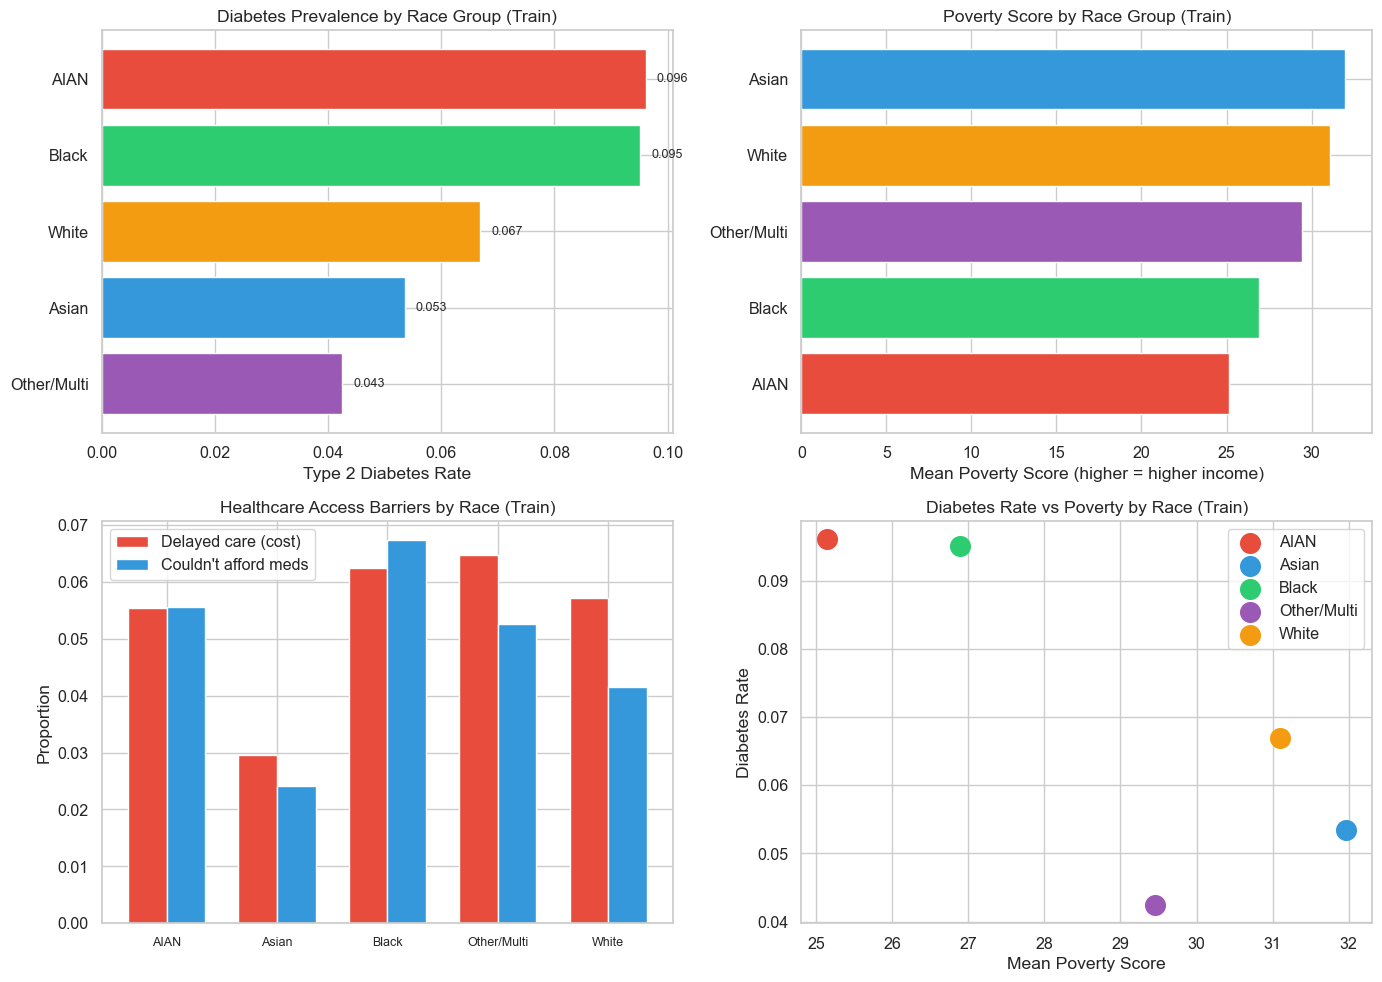

Saved socioeconomic analysis.


In [15]:
# ===== SOCIOECONOMIC & LABEL BIAS ANALYSIS (TRAIN SET ONLY) =====
train_eda = X_train.copy()
train_eda["diabetes_label"] = y_train.values
train_eda["race_group"] = protected_train.values

# Diabetes prevalence by race
prev_by_race = train_eda.groupby("race_group")["diabetes_label"].agg(["mean", "count"]).round(4)
prev_by_race.columns = ["diabetes_rate", "n"]
print("=== Diabetes Prevalence by Race (TRAIN) ===")
display(prev_by_race.sort_values("diabetes_rate", ascending=False))

# Poverty by race
print("\n=== Mean POVERTY by Race (higher = higher income) ===")
print(train_eda.groupby("race_group")["POVERTY"].mean().round(2).sort_values())

# IPUMS NHIS coding for DELAYCOST: 0=NIU, 1=No, 2=Yes (delayed care due to cost)
# IPUMS NHIS coding for YBARMEDS:  0=NIU, 1=No, 2=Yes (couldn't afford meds)
# After NIU replacement (Cell 19), remaining valid values are 1 (No) and 2 (Yes).
# We compute the barrier rate as the proportion answering "Yes".
#
# IMPORTANT: Print a sanity check so the user can verify against the IPUMS codebook.
# If the coding in your extract is 1=Yes/2=No (non-IPUMS convention), flip the logic.
print("\n=== CODING VERIFICATION (check against your IPUMS codebook) ===")
for barrier_col in ["DELAYCOST", "YBARMEDS"]:
    valid = train_eda[barrier_col].dropna()
    valid_12 = valid[valid.isin([1, 2])]
    print(f"  {barrier_col} value counts (should be 1=No, 2=Yes in IPUMS):")
    print(f"    1: {(valid_12 == 1).sum():,}  |  2: {(valid_12 == 2).sum():,}")
    print(f"    If 2=Yes, barrier rate = {(valid_12 == 2).mean():.3f}")
    print(f"    If 1=Yes, barrier rate = {(valid_12 == 1).mean():.3f}")
    print()

# Assuming IPUMS convention: 1=No, 2=Yes → barrier rate = proportion of 2s
BARRIER_YES_CODE = 2

delay = train_eda[train_eda["DELAYCOST"].isin([1, 2])].groupby("race_group")["DELAYCOST"].apply(
    lambda x: (x == BARRIER_YES_CODE).mean()).round(4)
meds = train_eda[train_eda["YBARMEDS"].isin([1, 2])].groupby("race_group")["YBARMEDS"].apply(
    lambda x: (x == BARRIER_YES_CODE).mean()).round(4)

print("=== Healthcare Access Barriers by Race (TRAIN) ===")
print(f"(Barrier = proportion answering code {BARRIER_YES_CODE})")
barrier_df = pd.DataFrame({"delayed_care_cost": delay, "couldnt_afford_meds": meds}).sort_index()
display(barrier_df)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
race_colors = {"AIAN": "#e74c3c", "Asian": "#3498db", "Black": "#2ecc71",
               "Other/Multi": "#9b59b6", "White": "#f39c12"}

# Diabetes prevalence
prev_sorted = prev_by_race.sort_values("diabetes_rate")
colors = [race_colors.get(g, "#333") for g in prev_sorted.index]
axes[0][0].barh(prev_sorted.index, prev_sorted["diabetes_rate"], color=colors)
axes[0][0].set_xlabel("Type 2 Diabetes Rate")
axes[0][0].set_title("Diabetes Prevalence by Race Group (Train)")
for i, (idx, row) in enumerate(prev_sorted.iterrows()):
    axes[0][0].text(row["diabetes_rate"] + 0.002, i, f"{row['diabetes_rate']:.3f}", va="center", fontsize=9)

# Poverty
pov = train_eda.groupby("race_group")["POVERTY"].mean().sort_values()
colors_pov = [race_colors.get(g, "#333") for g in pov.index]
axes[0][1].barh(pov.index, pov.values, color=colors_pov)
axes[0][1].set_xlabel("Mean Poverty Score (higher = higher income)")
axes[0][1].set_title("Poverty Score by Race Group (Train)")

# Healthcare barriers
x = np.arange(len(barrier_df))
w = 0.35
axes[1][0].bar(x - w / 2, barrier_df["delayed_care_cost"], w, label="Delayed care (cost)", color="#e74c3c")
axes[1][0].bar(x + w / 2, barrier_df["couldnt_afford_meds"], w, label="Couldn't afford meds", color="#3498db")
axes[1][0].set_xticks(x)
axes[1][0].set_xticklabels(barrier_df.index, fontsize=9)
axes[1][0].set_ylabel("Proportion")
axes[1][0].set_title("Healthcare Access Barriers by Race (Train)")
axes[1][0].legend()

# Diabetes rate vs poverty
for g in sorted(train_eda["race_group"].unique()):
    sub = train_eda[train_eda["race_group"] == g]
    axes[1][1].scatter(sub["POVERTY"].mean(), sub["diabetes_label"].mean(),
                       s=200, label=g, color=race_colors.get(g, "#333"), zorder=5)
axes[1][1].set_xlabel("Mean Poverty Score")
axes[1][1].set_ylabel("Diabetes Rate")
axes[1][1].set_title("Diabetes Rate vs Poverty by Race (Train)")
axes[1][1].legend()

plt.tight_layout()
plt.savefig(output_dir / "socioeconomic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved socioeconomic analysis.")

### Reusable Helper Functions

All subgroup metric computation is centralised here to avoid code duplication.

In [16]:
def build_group_metrics_df(y_true, y_pred, y_prob, protected_eval, protected_col="race_group"):
    """Unified function for computing group-level fairness metrics."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    protected_eval = np.array(protected_eval)

    rows = []
    for grp in sorted(set(protected_eval)):
        mask = protected_eval == grp
        yt, yp, ypr = y_true[mask], y_pred[mask], y_prob[mask]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        ppv = precision_score(yt, yp, zero_division=0)

        try:
            brier = brier_score_loss(yt, ypr)
        except ValueError:
            brier = np.nan

        rows.append({
            protected_col: grp,
            "n_samples": len(yt),
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "positive_rate_true": round(yt.mean(), 4),
            "predicted_positive_rate": round(yp.mean(), 4),
            "accuracy": round(accuracy_score(yt, yp), 4),
            "precision": round(ppv, 4),
            "tpr": round(tpr, 4), "fpr": round(fpr, 4),
            "tnr": round(tnr, 4), "fnr": round(fnr, 4),
            "f1": round(f1_score(yt, yp, zero_division=0), 4),
            "brier_score": round(brier, 4) if not np.isnan(brier) else np.nan
        })

    return pd.DataFrame(rows).sort_values(protected_col).reset_index(drop=True)

def compute_overall_metrics_from_probs(y_true, y_prob, threshold):
    y_pred_thr = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred_thr),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_thr),
        "precision": precision_score(y_true, y_pred_thr, zero_division=0),
        "recall": recall_score(y_true, y_pred_thr, zero_division=0),
        "f1": f1_score(y_true, y_pred_thr, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

def compute_gap_summary(group_df):
    return {
        "max_tpr_gap": group_df["tpr"].max() - group_df["tpr"].min(),
        "max_fpr_gap": group_df["fpr"].max() - group_df["fpr"].min(),
        "max_fnr_gap": group_df["fnr"].max() - group_df["fnr"].min(),
        "max_pred_pos_gap": group_df["predicted_positive_rate"].max() - group_df["predicted_positive_rate"].min()
    }

def compute_reweights(y, protected, max_weight=10.0):
    """Compute sample weights for group x label balancing.
    
    FIX #10: Added max_weight clipping to prevent extreme weights
    for small group x label cells (e.g. AIAN positives).
    """
    y, p = np.array(y), np.array(protected)
    n = len(y)
    groups = sorted(set(p))
    weights = np.ones(n)
    for g in groups:
        for label in [0, 1]:
            mask = (p == g) & (y == label)
            expected = n / (len(groups) * 2)
            actual = mask.sum()
            if actual > 0:
                w = expected / actual
                w = min(w, max_weight)  # FIX #10: clip extreme weights
                weights[mask] = w
    
    # Report weight distribution
    print(f"Reweighting stats: min={weights.min():.2f}, max={weights.max():.2f}, "
          f"mean={weights.mean():.2f}, std={weights.std():.2f}")
    return weights

print("All utility functions defined.")

All utility functions defined.


In [17]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features)
    ]
)

print("Preprocessor ready.")
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Preprocessor ready.
Categorical features: ['USBORN', 'CITIZEN', 'EDUC', 'USUALPL', 'REGION', 'EMPSTAT', 'DELAYCOST', 'YBARCARE', 'YBARMEDS', 'HEALTH']
Numerical features: ['YEAR', 'AGE', 'POVERTY', 'HEIGHT', 'WEIGHT']


## Baseline Logistic Regression

In [18]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

print("Baseline logistic regression pipeline fitted successfully.")
print("Categorical features used:", categorical_features)
print("Numerical features used:", numerical_features)

Baseline logistic regression pipeline fitted successfully.
Categorical features used: ['USBORN', 'CITIZEN', 'EDUC', 'USUALPL', 'REGION', 'EMPSTAT', 'DELAYCOST', 'YBARCARE', 'YBARMEDS', 'HEALTH']
Numerical features used: ['YEAR', 'AGE', 'POVERTY', 'HEIGHT', 'WEIGHT']


In [19]:
y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

overall_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob)
}

print("Overall metrics:")
for k, v in overall_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Overall metrics:
accuracy: 0.7294
balanced_accuracy: 0.7731
precision: 0.1796
recall: 0.8238
f1: 0.2950
roc_auc: 0.8460

Confusion matrix:
[[23788  9138]
 [  428  2001]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.72      0.83     32926
           1       0.18      0.82      0.29      2429

    accuracy                           0.73     35355
   macro avg       0.58      0.77      0.56     35355
weighted avg       0.93      0.73      0.80     35355



In [20]:
group_metrics_df = build_group_metrics_df(
    y_true=y_test, y_pred=y_pred, y_prob=y_prob,
    protected_eval=protected_test, protected_col="race_group"
)
display(group_metrics_df.round(4))

,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1,brier_score
0,AIAN,351,26,89,229,7,0.0940,0.3276,0.7265,0.2261,0.7879,0.2799,0.7201,0.2121,0.3514,0.1845
1,Asian,2280,84,361,1797,38,0.0535,0.1952,0.8250,0.1888,0.6885,0.1673,0.8327,0.3115,0.2963,0.1166
2,Black,4098,342,1241,2467,48,0.0952,0.3863,0.6855,0.2160,0.8769,0.3347,0.6653,0.1231,0.3467,0.1970
3,Other/Multi,1207,42,183,973,9,0.0423,0.1864,0.8409,0.1867,0.8235,0.1583,0.8417,0.1765,0.3043,0.1010
4,White,27419,1507,7264,18322,326,0.0669,0.3199,0.7232,0.1718,0.8221,0.2839,0.7161,0.1779,0.2842,0.1765


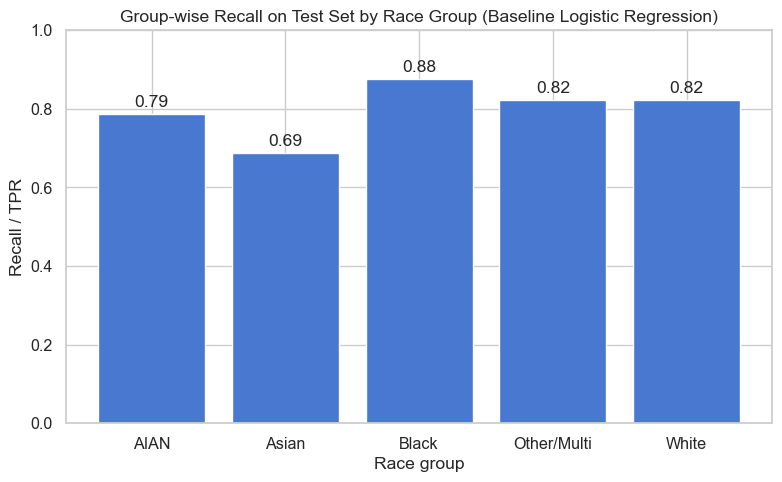

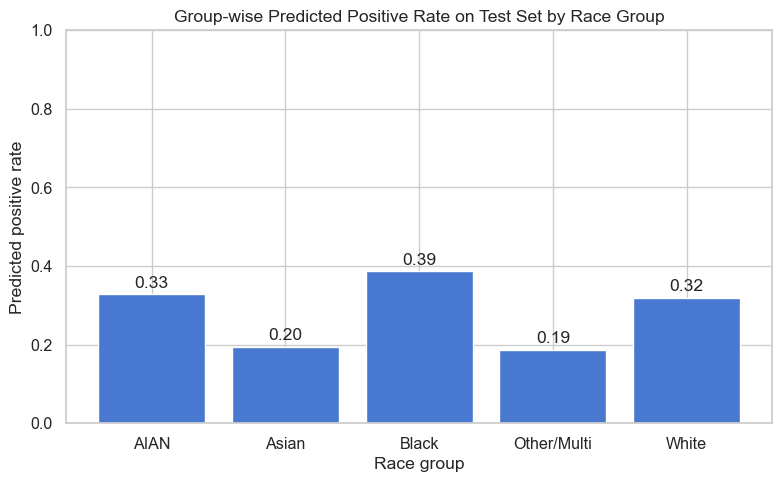

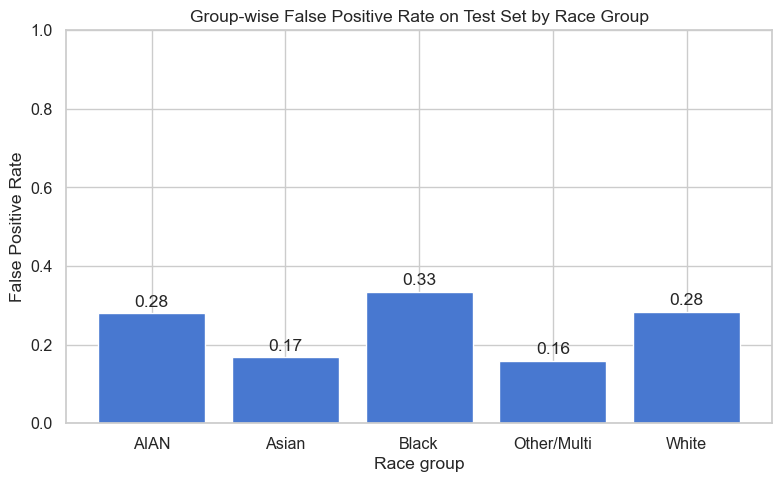

In [21]:
plot_df = group_metrics_df.copy()

# Plot 1: TPR / Recall
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["tpr"])
plt.xlabel("Race group")
plt.ylabel("Recall / TPR")
plt.title("Group-wise Recall on Test Set by Race Group (Baseline Logistic Regression)")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["tpr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Plot 2: Predicted positive rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["predicted_positive_rate"])
plt.xlabel("Race group")
plt.ylabel("Predicted positive rate")
plt.title("Group-wise Predicted Positive Rate on Test Set by Race Group")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["predicted_positive_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Plot 3: False Positive Rate
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["race_group"], plot_df["fpr"])
plt.xlabel("Race group")
plt.ylabel("False Positive Rate")
plt.title("Group-wise False Positive Rate on Test Set by Race Group")
plt.ylim(0, 1)

for bar, val in zip(bars, plot_df["fpr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [22]:
# NOTE: These CSVs capture the pre-tuning baseline (C=1.0, default).
# After GridSearchCV below, tuned-model results are saved separately.
pd.DataFrame([overall_metrics]).to_csv(
    output_dir / "baseline_logreg_C1_overall_metrics.csv",
    index=False
)

group_metrics_df.to_csv(
    output_dir / "baseline_logreg_C1_group_metrics.csv",
    index=False
)

print("Saved (pre-tuning baseline, C=1.0):")
print("- outputs_2/baseline_logreg_C1_overall_metrics.csv")
print("- outputs_2/baseline_logreg_C1_group_metrics.csv")

Saved (pre-tuning baseline, C=1.0):
- outputs_2/baseline_logreg_C1_overall_metrics.csv
- outputs_2/baseline_logreg_C1_group_metrics.csv


## Hyperparameter Tuning — Logistic Regression (GridSearchCV)

We use `GridSearchCV` with 5-fold stratified cross-validation on the training set to tune the regularisation strength `C` of logistic regression. Scoring is `balanced_accuracy` to account for class imbalance.

In [23]:
# Extended search space: include values below 0.01 to avoid boundary optimum
param_grid = {"classifier__C": [0.001, 0.01, 0.1, 1.0, 10.0]}

gs_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

grid_search = GridSearchCV(
    gs_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_C = grid_search.best_params_["classifier__C"]
print("Best params:", grid_search.best_params_)
print(f"Best CV balanced_accuracy: {grid_search.best_score_:.4f}")

if best_C == min(param_grid["classifier__C"]):
    print("WARNING: best C is at the lower boundary of the search space. "
          "Consider extending param_grid to smaller values.")
elif best_C == max(param_grid["classifier__C"]):
    print("WARNING: best C is at the upper boundary of the search space. "
          "Consider extending param_grid to larger values.")

# Update pipeline and recompute ALL downstream predictions/metrics
# so that subsequent analysis, fairness evaluation, and saved CSVs are consistent.
log_reg_pipeline = grid_search.best_estimator_

y_pred   = log_reg_pipeline.predict(X_test)
y_prob   = log_reg_pipeline.predict_proba(X_test)[:, 1]

# best_C is intentionally NOT added to overall_metrics to keep the schema
# consistent with overall_metrics_no_weight and overall_metrics_rf (no such key).
print(f"GridSearchCV best C: {best_C}")

overall_metrics = {
    "accuracy":          accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision":         precision_score(y_test, y_pred, zero_division=0),
    "recall":            recall_score(y_test, y_pred, zero_division=0),
    "f1":                f1_score(y_test, y_pred, zero_division=0),
    "roc_auc":           roc_auc_score(y_test, y_prob),
}

group_metrics_df = build_group_metrics_df(
    y_true=y_test, y_pred=y_pred, y_prob=y_prob,
    protected_eval=protected_test, protected_col="race_group"
)

print("\nTuned model — overall metrics:")
for k, v in overall_metrics.items():
    print(f"  {k}: {v}")

# Save tuned-model results (distinct from the C=1.0 baseline saved in Cell 37)
pd.DataFrame([overall_metrics]).to_csv(
    output_dir / "tuned_logreg_overall_metrics.csv", index=False
)
group_metrics_df.to_csv(
    output_dir / "tuned_logreg_group_metrics.csv", index=False
)

cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_classifier__C", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")
display(cv_results.round(4))
cv_results.to_csv(output_dir / "logreg_gridsearch_results.csv", index=False)
print("Saved tuned-model CSVs to outputs_2/")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'classifier__C': 1.0}
Best CV balanced_accuracy: 0.7782
GridSearchCV best C: 1.0

Tuned model — overall metrics:
  accuracy: 0.7294300664686749
  balanced_accuracy: 0.7731321833080191
  precision: 0.17963910584433074
  recall: 0.8237958007410457
  f1: 0.29495872641509435
  roc_auc: 0.845962672086741


,param_classifier__C,mean_test_score,std_test_score,rank_test_score
3,1.000,0.7782,0.0073,1
4,10.000,0.7782,0.0073,2
2,0.100,0.7782,0.0072,3
1,0.010,0.7776,0.0071,4
0,0.001,0.7747,0.0076,5


Saved tuned-model CSVs to outputs_2/


## Logistic Regression without class_weight (Tuned)

In [24]:
param_grid_unw = {"classifier__C": [0.001, 0.01, 0.1, 1.0, 10.0]}

gs_unw_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

grid_search_unw = GridSearchCV(
    gs_unw_pipeline,
    param_grid=param_grid_unw,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search_unw.fit(X_train, y_train)

log_reg_no_weight = grid_search_unw.best_estimator_
print(f"Unweighted LR best C: {grid_search_unw.best_params_}")
print(f"Best CV balanced_accuracy: {grid_search_unw.best_score_:.4f}")

y_pred_no_weight = log_reg_no_weight.predict(X_test)
y_prob_no_weight = log_reg_no_weight.predict_proba(X_test)[:, 1]

overall_metrics_no_weight = {
    "accuracy": accuracy_score(y_test, y_pred_no_weight),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_no_weight),
    "precision": precision_score(y_test, y_pred_no_weight, zero_division=0),
    "recall": recall_score(y_test, y_pred_no_weight, zero_division=0),
    "f1": f1_score(y_test, y_pred_no_weight, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_no_weight)
}

print("\nOverall metrics (no class_weight, TUNED):")
for k, v in overall_metrics_no_weight.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_no_weight))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Unweighted LR best C: {'classifier__C': 1.0}
Best CV balanced_accuracy: 0.5043

Overall metrics (no class_weight, TUNED):
accuracy: 0.9309
balanced_accuracy: 0.5059
precision: 0.4103
recall: 0.0132
f1: 0.0255
roc_auc: 0.8269

Confusion matrix:
[[32880    46]
 [ 2397    32]]


In [25]:
group_metrics_no_weight_df = build_group_metrics_df(
    y_true=y_test, y_pred=y_pred_no_weight, y_prob=y_prob_no_weight,
    protected_eval=protected_test, protected_col="race_group"
)
display(group_metrics_no_weight_df.round(4))

,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1,brier_score
0,AIAN,351,0,3,315,33,0.0940,0.0085,0.8974,0.0000,0.0000,0.0094,0.9906,1.0000,0.0000,0.0849
1,Asian,2280,1,1,2157,121,0.0535,0.0009,0.9465,0.5000,0.0082,0.0005,0.9995,0.9918,0.0161,0.0463
2,Black,4098,5,9,3699,385,0.0952,0.0034,0.9039,0.3571,0.0128,0.0024,0.9976,0.9872,0.0248,0.0777
3,Other/Multi,1207,0,1,1155,51,0.0423,0.0008,0.9569,0.0000,0.0000,0.0009,0.9991,1.0000,0.0000,0.0363
4,White,27419,26,32,25554,1807,0.0669,0.0021,0.9329,0.4483,0.0142,0.0013,0.9987,0.9858,0.0275,0.0561


In [26]:
comparison_df = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight}
]).round(4)

display(comparison_df)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,logreg_balanced,0.7294,0.7731,0.1796,0.8238,0.2950,0.8460
1,logreg_unweighted,0.9309,0.5059,0.4103,0.0132,0.0255,0.8269


The side-by-side comparison highlights a strong threshold-level trade-off. The class-weighted logistic regression model sacrifices overall accuracy in order to identify positive cases, while the unweighted model achieves superficially high accuracy by almost always predicting the majority class. This contrast shows why accuracy alone is not sufficient for evaluating imbalanced healthcare classification tasks.

In [27]:
pd.DataFrame([overall_metrics_no_weight]).to_csv(
    output_dir / "logreg_no_weight_overall_metrics.csv",
    index=False
)

group_metrics_no_weight_df.to_csv(
    output_dir / "logreg_no_weight_group_metrics.csv",
    index=False
)

comparison_df.to_csv(
    output_dir / "logreg_weight_comparison.csv",
    index=False
)

print("Saved:")
print("- outputs/logreg_no_weight_overall_metrics.csv")
print("- outputs/logreg_no_weight_group_metrics.csv")
print("- outputs/logreg_weight_comparison.csv")

Saved:
- outputs/logreg_no_weight_overall_metrics.csv
- outputs/logreg_no_weight_group_metrics.csv
- outputs/logreg_weight_comparison.csv


## Model Comparison and Fairness Analysis

In [28]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        max_depth=15,
        min_samples_leaf=10,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random forest pipeline fitted successfully.")

Random forest pipeline fitted successfully.


In [29]:
overall_metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_rf)
}

print("Overall metrics (Random Forest):")
for k, v in overall_metrics_rf.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Overall metrics (Random Forest):
accuracy: 0.7624
balanced_accuracy: 0.7794
precision: 0.1970
recall: 0.7991
f1: 0.3161
roc_auc: 0.8554

Confusion matrix:
[[25014  7912]
 [  488  1941]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     32926
           1       0.20      0.80      0.32      2429

    accuracy                           0.76     35355
   macro avg       0.59      0.78      0.59     35355
weighted avg       0.93      0.76      0.82     35355



### ROC Curve Comparison

The ROC curves below show that the weighted and unweighted logistic regression models have very similar ranking performance, even though their thresholded classification behavior differs dramatically. This supports the argument that ROC-AUC alone is not sufficient to evaluate screening performance under class imbalance.

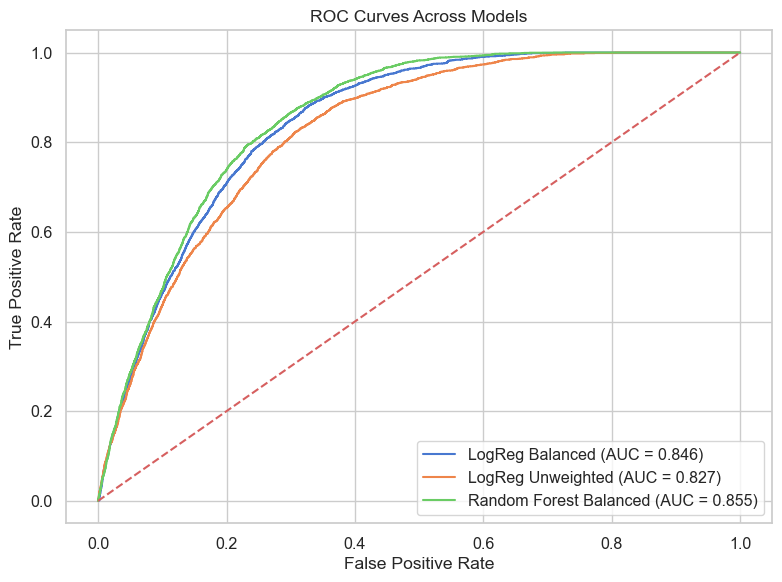

In [30]:
fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y_test, y_prob)
fpr_lr_unw, tpr_lr_unw, _ = roc_curve(y_test, y_prob_no_weight)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr_bal = auc(fpr_lr_bal, tpr_lr_bal)
auc_lr_unw = auc(fpr_lr_unw, tpr_lr_unw)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_bal, tpr_lr_bal, label=f"LogReg Balanced (AUC = {auc_lr_bal:.3f})")
plt.plot(fpr_lr_unw, tpr_lr_unw, label=f"LogReg Unweighted (AUC = {auc_lr_unw:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest Balanced (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Across Models")
plt.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curve Comparison

Because the dataset is imbalanced (positive rate ~7%), Precision-Recall curves provide a more informative view of model performance than ROC curves. A model with high ROC-AUC can still have low precision in imbalanced settings.

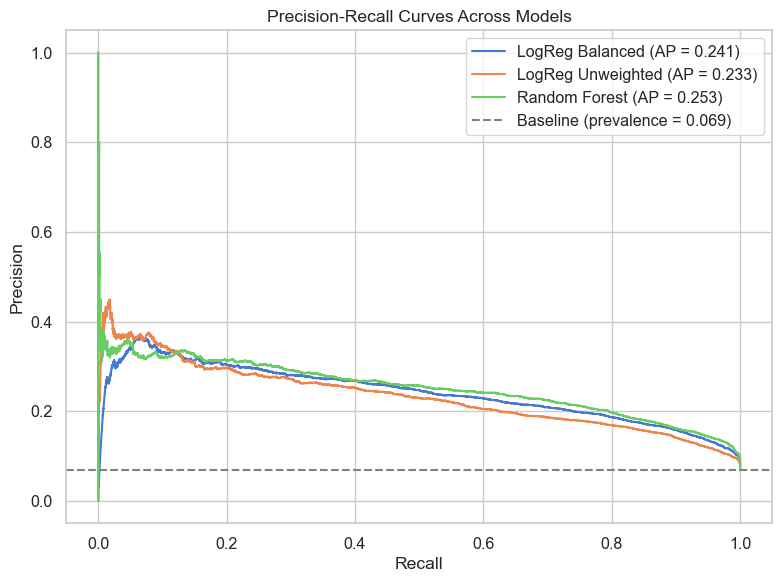

Average Precision — LR: 0.241, Unweighted: 0.233, RF: 0.253


In [31]:
# ===== PRECISION-RECALL CURVES =====
pr_lr_pre, pr_lr_rec, _ = precision_recall_curve(y_test, y_prob)
pr_unw_pre, pr_unw_rec, _ = precision_recall_curve(y_test, y_prob_no_weight)
pr_rf_pre, pr_rf_rec, _ = precision_recall_curve(y_test, y_prob_rf)

ap_lr = average_precision_score(y_test, y_prob)
ap_unw = average_precision_score(y_test, y_prob_no_weight)
ap_rf = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(pr_lr_rec, pr_lr_pre, label=f"LogReg Balanced (AP = {ap_lr:.3f})")
plt.plot(pr_unw_rec, pr_unw_pre, label=f"LogReg Unweighted (AP = {ap_unw:.3f})")
plt.plot(pr_rf_rec, pr_rf_pre, label=f"Random Forest (AP = {ap_rf:.3f})")

baseline = np.array(y_test).mean()
plt.axhline(y=baseline, linestyle="--", color="gray", label=f"Baseline (prevalence = {baseline:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Across Models")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average Precision — LR: {ap_lr:.3f}, Unweighted: {ap_unw:.3f}, RF: {ap_rf:.3f}")

The weighted and unweighted logistic regression models have nearly identical ROC curves and AUC values, indicating similar ranking performance. However, their classification behavior at the default threshold differs substantially, showing that ROC-AUC alone is insufficient for evaluating utility in this imbalanced setting.

In [32]:
comparison_df_all = pd.DataFrame([
    {"model": "logreg_balanced", **overall_metrics},
    {"model": "logreg_unweighted", **overall_metrics_no_weight},
    {"model": "random_forest_balanced", **overall_metrics_rf}
]).round(4)

display(comparison_df_all)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,logreg_balanced,0.7294,0.7731,0.1796,0.8238,0.2950,0.8460
1,logreg_unweighted,0.9309,0.5059,0.4103,0.0132,0.0255,0.8269
2,random_forest_balanced,0.7624,0.7794,0.1970,0.7991,0.3161,0.8554


To better understand what the balanced logistic regression model was using, we inspected the learned coefficients after one-hot encoding and the random forest feature importances. The largest-magnitude logistic regression coefficients were associated with employment status, self-reported health, age, and weight. The random forest identified AGE, WEIGHT, HEALTH, and POVERTY as the most important variables. These results suggest the classifier relies heavily on health and demographic variables, with socioeconomic factors playing a secondary but non-trivial role.

=== Top 20 Logistic Regression Coefficients ===


,feature,coefficient,abs_coefficient
0,HEALTH_1.0,-1.660141,1.660141
1,AGE,1.187148,1.187148
2,HEALTH_5.0,1.034546,1.034546
3,WEIGHT,0.809844,0.809844
4,HEALTH_4.0,0.779754,0.779754
5,USUALPL_1.0,-0.760935,0.760935
6,HEALTH_2.0,-0.635580,0.635580
7,USUALPL_2.0,0.506025,0.506025
8,EMPSTAT_100.0,-0.372581,0.372581
9,YBARMEDS_1.0,-0.356024,0.356024



=== Random Forest Feature Importances (Grouped by Variable) ===


,feature,importance
0,AGE,0.321187
1,HEALTH,0.242838
2,WEIGHT,0.112987
3,EMPSTAT,0.112335
4,HEIGHT,0.056708
5,EDUC,0.048538
6,POVERTY,0.027536
7,USUALPL,0.020065
8,REGION,0.018193
9,YEAR,0.014603


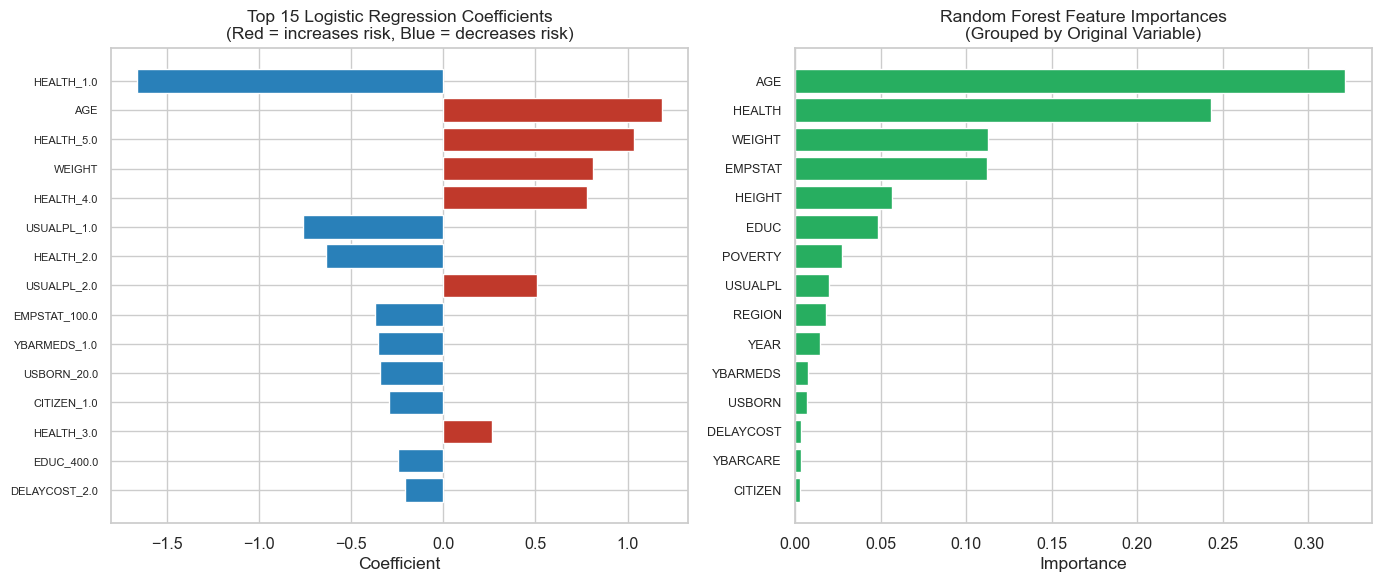

Saved feature importance files.


In [33]:
# ===== LOGISTIC REGRESSION COEFFICIENTS =====
cat_feature_names = list(
    log_reg_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)
all_feature_names = cat_feature_names + numerical_features

logreg_coefs = log_reg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": logreg_coefs,
    "abs_coefficient": np.abs(logreg_coefs)
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

print("=== Top 20 Logistic Regression Coefficients ===")
display(coef_df.head(20))

# ===== RANDOM FOREST FEATURE IMPORTANCES =====
rf_importances = rf_pipeline.named_steps["classifier"].feature_importances_

imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Group importances by original variable (sum one-hot columns)
grouped_rows = []
for cf in categorical_features:
    mask = [f.startswith(cf + "_") for f in all_feature_names]
    grouped_rows.append({"feature": cf, "importance": rf_importances[mask].sum()})
for nf in numerical_features:
    idx = all_feature_names.index(nf)
    grouped_rows.append({"feature": nf, "importance": rf_importances[idx]})

grouped_imp_df = pd.DataFrame(grouped_rows).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n=== Random Forest Feature Importances (Grouped by Variable) ===")
display(grouped_imp_df)

# ===== PLOTS =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LR top 15
top_lr = coef_df.head(15)
colors = ["#c0392b" if c > 0 else "#2980b9" for c in top_lr["coefficient"]]
axes[0].barh(range(len(top_lr)), top_lr["coefficient"].values, color=colors)
axes[0].set_yticks(range(len(top_lr)))
axes[0].set_yticklabels(top_lr["feature"].values, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Logistic Regression Coefficients\n(Red = increases risk, Blue = decreases risk)")
axes[0].set_xlabel("Coefficient")

# RF grouped
axes[1].barh(range(len(grouped_imp_df)), grouped_imp_df["importance"].values, color="#27ae60")
axes[1].set_yticks(range(len(grouped_imp_df)))
axes[1].set_yticklabels(grouped_imp_df["feature"].values, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title("Random Forest Feature Importances\n(Grouped by Original Variable)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(output_dir / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Save CSVs
coef_df.to_csv(output_dir / "logreg_coefficients_ranked.csv", index=False)
imp_df.to_csv(output_dir / "rf_importances_detailed.csv", index=False)
grouped_imp_df.to_csv(output_dir / "rf_importances_grouped.csv", index=False)
print("Saved feature importance files.")

### Bootstrap Confidence Intervals

To address the instability of fairness metrics for small subgroups (particularly AIAN with ~330 test observations), we compute 95% bootstrap confidence intervals for group-level TPR, FPR, and F1 across 1,000 resamples.

Running bootstrap for Logistic Regression (1000 iterations)...
Running bootstrap for Random Forest (1000 iterations)...

=== Logistic Regression — 95% Bootstrap CI ===


,race_group,tpr_mean,tpr_lo,tpr_hi,tpr_width,fpr_mean,fpr_lo,fpr_hi,fpr_width,f1_mean,f1_lo,f1_hi,f1_width
0,AIAN,0.7865,0.6250,0.9091,0.2841,0.2797,0.2308,0.3301,0.0993,0.3475,0.2424,0.4485,0.2061
1,Asian,0.6887,0.6103,0.7727,0.1624,0.1673,0.1514,0.1827,0.0313,0.2951,0.2474,0.3407,0.0933
2,Black,0.8771,0.8433,0.9086,0.0653,0.3349,0.3201,0.3500,0.0299,0.3462,0.3185,0.3724,0.0539
3,Other/Multi,0.8274,0.7174,0.9216,0.2042,0.1586,0.1379,0.1795,0.0416,0.3045,0.2374,0.3741,0.1367
4,White,0.8217,0.8028,0.8388,0.0360,0.2840,0.2787,0.2893,0.0106,0.2842,0.2722,0.2957,0.0235



=== Random Forest — 95% Bootstrap CI ===


,race_group,tpr_mean,tpr_lo,tpr_hi,tpr_width,fpr_mean,fpr_lo,fpr_hi,fpr_width,f1_mean,f1_lo,f1_hi,f1_width
0,AIAN,0.7569,0.5926,0.8913,0.2987,0.2422,0.1926,0.2862,0.0936,0.3664,0.2580,0.4754,0.2174
1,Asian,0.5907,0.5083,0.6750,0.1667,0.1154,0.1021,0.1288,0.0267,0.3240,0.2687,0.3783,0.1096
2,Black,0.8435,0.8048,0.8770,0.0722,0.2848,0.2697,0.2998,0.0301,0.3703,0.3418,0.3982,0.0564
3,Other/Multi,0.8077,0.6905,0.9153,0.2248,0.1126,0.0949,0.1303,0.0354,0.3696,0.2911,0.4492,0.1581
4,White,0.8038,0.7861,0.8216,0.0355,0.2503,0.2449,0.2557,0.0108,0.3036,0.2909,0.3159,0.0250


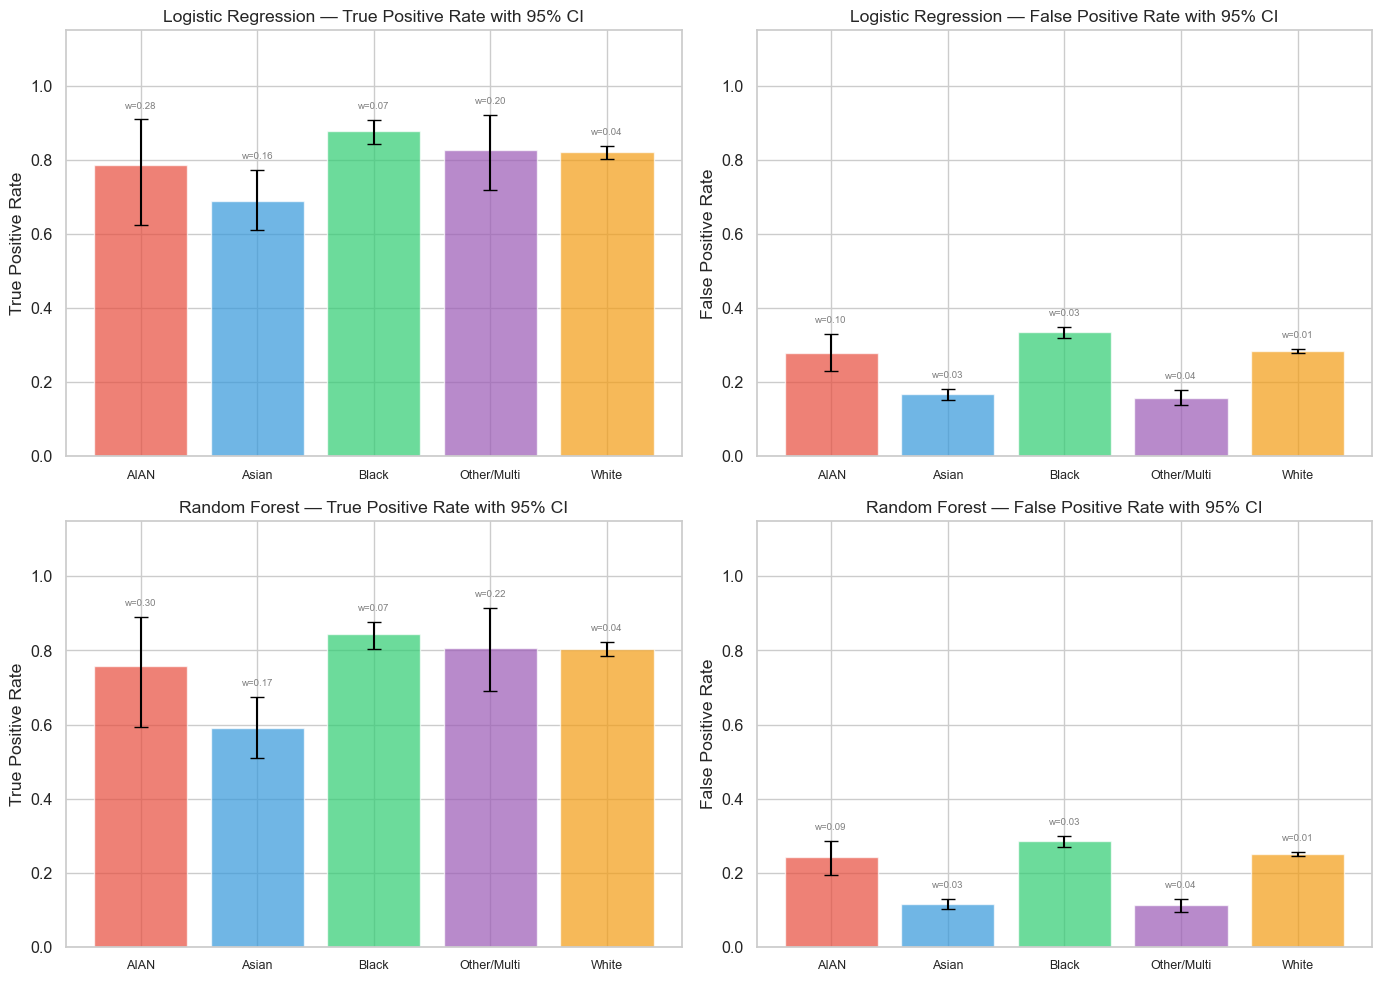

Saved bootstrap CI files.


In [34]:
# ===== BOOTSTRAP 95% CONFIDENCE INTERVALS =====
# were skipped entirely. This inflated TPR estimates for small groups (e.g. AIAN).
# Now, when a group has no positives in a bootstrap sample, we record TPR=0, FNR=1
# (the model cannot identify any positive if none exist in the sample).
# When a group has no negatives, we record FPR=0 (no false positives possible).
# We still skip groups with fewer than 5 total observations per resample to avoid
# degenerate metrics from near-empty samples.

def bootstrap_group_ci(y_true, y_pred, protected, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    groups = sorted(protected.unique())
    y_true, y_pred, protected = map(np.array, [y_true, y_pred, protected])
    metrics = ["tpr", "fpr", "fnr", "ppr", "precision", "f1"]
    results = {g: {m: [] for m in metrics} for g in groups}

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        for g in groups:
            mask = protected[idx] == g
            if mask.sum() < 5:
                continue
            yt, yp = y_true[idx][mask], y_pred[idx][mask]

            tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

            # FIX v3 #22: Handle edge cases without skipping
            n_pos = tp + fn  # actual positives in this resample
            n_neg = tn + fp  # actual negatives in this resample

            if n_pos > 0:
                tpr = tp / n_pos
                fnr = fn / n_pos
            else:
                # No positives in resample → TPR is 0 (nothing to detect)
                tpr = 0.0
                fnr = 1.0

            if n_neg > 0:
                fpr = fp / n_neg
            else:
                fpr = 0.0

            ppr = (tp + fp) / len(yt)
            pre = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            if (pre + tpr) > 0:
                f1 = 2 * pre * tpr / (pre + tpr)
            else:
                f1 = 0.0

            for k, v in zip(metrics, [tpr, fpr, fnr, ppr, pre, f1]):
                results[g][k].append(v)

    rows = []
    for g in groups:
        row = {"race_group": g}
        for m in metrics:
            v = results[g][m]
            if v:
                row[f"{m}_mean"] = round(np.mean(v), 4)
                row[f"{m}_lo"] = round(np.percentile(v, 2.5), 4)
                row[f"{m}_hi"] = round(np.percentile(v, 97.5), 4)
                row[f"{m}_width"] = round(row[f"{m}_hi"] - row[f"{m}_lo"], 4)
            else:
                row[f"{m}_mean"] = row[f"{m}_lo"] = row[f"{m}_hi"] = row[f"{m}_width"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

print("Running bootstrap for Logistic Regression (1000 iterations)...")
ci_lr = bootstrap_group_ci(y_test, y_pred, protected_test)

print("Running bootstrap for Random Forest (1000 iterations)...")
ci_rf = bootstrap_group_ci(y_test, y_pred_rf, protected_test)

# Display
for name, ci in [("Logistic Regression", ci_lr), ("Random Forest", ci_rf)]:
    print(f"\n=== {name} — 95% Bootstrap CI ===")
    display(ci[["race_group", "tpr_mean", "tpr_lo", "tpr_hi", "tpr_width",
                "fpr_mean", "fpr_lo", "fpr_hi", "fpr_width",
                "f1_mean", "f1_lo", "f1_hi", "f1_width"]])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col, metric, label in [(0, "tpr", "True Positive Rate"), (1, "fpr", "False Positive Rate")]:
    for row, (ci, title) in enumerate([(ci_lr, "Logistic Regression"), (ci_rf, "Random Forest")]):
        ax = axes[row][col]
        groups = ci["race_group"]
        x = np.arange(len(groups))
        means = ci[f"{metric}_mean"].values
        lo = ci[f"{metric}_lo"].values
        hi = ci[f"{metric}_hi"].values
        colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12"]
        ax.bar(x, means, color=colors, alpha=0.7)
        ax.errorbar(x, means, yerr=[means - lo, hi - means], fmt="none", ecolor="black", capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(groups, fontsize=9)
        ax.set_ylabel(label)
        ax.set_title(f"{title} — {label} with 95% CI")
        ax.set_ylim(0, 1.15)
        for i in range(len(groups)):
            w = hi[i] - lo[i]
            ax.text(i, hi[i] + 0.03, f"w={w:.2f}", ha="center", fontsize=7, color="gray")

plt.tight_layout()
plt.savefig(output_dir / "bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()

ci_lr.to_csv(output_dir / "bootstrap_ci_lr.csv", index=False)
ci_rf.to_csv(output_dir / "bootstrap_ci_rf.csv", index=False)
print("Saved bootstrap CI files.")

In [35]:
# Compute group metrics for both models (using the helper defined earlier)
group_metrics_logreg_df = build_group_metrics_df(
    y_true=y_test, y_pred=y_pred, y_prob=y_prob,
    protected_eval=protected_test, protected_col="race_group"
)

group_metrics_rf_df = build_group_metrics_df(
    y_true=y_test, y_pred=y_pred_rf, y_prob=y_prob_rf,
    protected_eval=protected_test, protected_col="race_group"
)

print("Balanced Logistic Regression:")
display(group_metrics_logreg_df.round(4))

print("Random Forest:")
display(group_metrics_rf_df.round(4))

Balanced Logistic Regression:


,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1,brier_score
0,AIAN,351,26,89,229,7,0.0940,0.3276,0.7265,0.2261,0.7879,0.2799,0.7201,0.2121,0.3514,0.1845
1,Asian,2280,84,361,1797,38,0.0535,0.1952,0.8250,0.1888,0.6885,0.1673,0.8327,0.3115,0.2963,0.1166
2,Black,4098,342,1241,2467,48,0.0952,0.3863,0.6855,0.2160,0.8769,0.3347,0.6653,0.1231,0.3467,0.1970
3,Other/Multi,1207,42,183,973,9,0.0423,0.1864,0.8409,0.1867,0.8235,0.1583,0.8417,0.1765,0.3043,0.1010
4,White,27419,1507,7264,18322,326,0.0669,0.3199,0.7232,0.1718,0.8221,0.2839,0.7161,0.1779,0.2842,0.1765


Random Forest:


,race_group,n_samples,tp,fp,tn,fn,positive_rate_true,predicted_positive_rate,accuracy,precision,tpr,fpr,tnr,fnr,f1,brier_score
0,AIAN,351,25,77,241,8,0.0940,0.2906,0.7578,0.2451,0.7576,0.2421,0.7579,0.2424,0.3704,0.1513
1,Asian,2280,72,249,1909,50,0.0535,0.1408,0.8689,0.2243,0.5902,0.1154,0.8846,0.4098,0.3251,0.0857
2,Black,4098,329,1055,2653,61,0.0952,0.3377,0.7277,0.2377,0.8436,0.2845,0.7155,0.1564,0.3709,0.1634
3,Other/Multi,1207,41,130,1026,10,0.0423,0.1417,0.8840,0.2398,0.8039,0.1125,0.8875,0.1961,0.3694,0.0747
4,White,27419,1474,6401,19185,359,0.0669,0.2872,0.7535,0.1872,0.8041,0.2502,0.7498,0.1959,0.3037,0.1494


### Extended Fairness Metrics: Equalized Odds and Brier Score

To provide a more comprehensive fairness evaluation, we compute Equalized Odds (TPR and FPR gaps across groups) and Brier Score (calibration quality) per group, as suggested by peer reviewers.

=== Logistic Regression — Extended Fairness ===


,race_group,n_samples,positive_rate_true,tpr,fpr,fnr,predicted_positive_rate,precision,f1,brier_score
0,AIAN,351,0.0940,0.7879,0.2799,0.2121,0.3276,0.2261,0.3514,0.1845
1,Asian,2280,0.0535,0.6885,0.1673,0.3115,0.1952,0.1888,0.2963,0.1166
2,Black,4098,0.0952,0.8769,0.3347,0.1231,0.3863,0.2160,0.3467,0.1970
3,Other/Multi,1207,0.0423,0.8235,0.1583,0.1765,0.1864,0.1867,0.3043,0.1010
4,White,27419,0.0669,0.8221,0.2839,0.1779,0.3199,0.1718,0.2842,0.1765



Equalized Odds — TPR gap: 0.1884, FPR gap: 0.1764
Brier Score gap: 0.0960

=== Random Forest — Extended Fairness ===


,race_group,n_samples,positive_rate_true,tpr,fpr,fnr,predicted_positive_rate,precision,f1,brier_score
0,AIAN,351,0.0940,0.7576,0.2421,0.2424,0.2906,0.2451,0.3704,0.1513
1,Asian,2280,0.0535,0.5902,0.1154,0.4098,0.1408,0.2243,0.3251,0.0857
2,Black,4098,0.0952,0.8436,0.2845,0.1564,0.3377,0.2377,0.3709,0.1634
3,Other/Multi,1207,0.0423,0.8039,0.1125,0.1961,0.1417,0.2398,0.3694,0.0747
4,White,27419,0.0669,0.8041,0.2502,0.1959,0.2872,0.1872,0.3037,0.1494



Equalized Odds — TPR gap: 0.2534, FPR gap: 0.1720
Brier Score gap: 0.0887


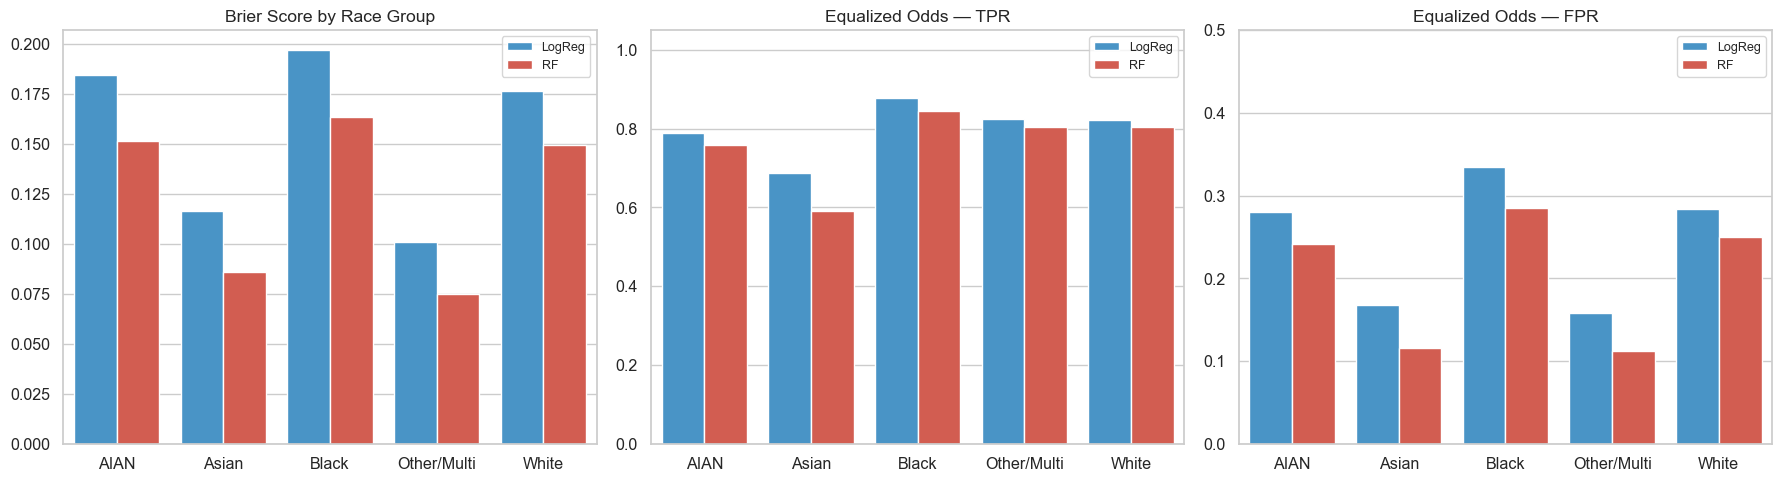

Saved extended fairness files.


In [36]:
# ===== EXTENDED FAIRNESS METRICS: EQUALIZED ODDS + BRIER SCORE =====
# Uses the unified build_group_metrics_df which already includes Brier score

fm_lr = build_group_metrics_df(y_test, y_pred, y_prob, protected_test)
fm_rf = build_group_metrics_df(y_test, y_pred_rf, y_prob_rf, protected_test)

print("=== Logistic Regression — Extended Fairness ===")
display(fm_lr[["race_group", "n_samples", "positive_rate_true", "tpr", "fpr", "fnr",
               "predicted_positive_rate", "precision", "f1", "brier_score"]])
print(f"\nEqualized Odds — TPR gap: {fm_lr['tpr'].max()-fm_lr['tpr'].min():.4f}, "
      f"FPR gap: {fm_lr['fpr'].max()-fm_lr['fpr'].min():.4f}")
print(f"Brier Score gap: {fm_lr['brier_score'].max()-fm_lr['brier_score'].min():.4f}")

print("\n=== Random Forest — Extended Fairness ===")
display(fm_rf[["race_group", "n_samples", "positive_rate_true", "tpr", "fpr", "fnr",
               "predicted_positive_rate", "precision", "f1", "brier_score"]])
print(f"\nEqualized Odds — TPR gap: {fm_rf['tpr'].max()-fm_rf['tpr'].min():.4f}, "
      f"FPR gap: {fm_rf['fpr'].max()-fm_rf['fpr'].min():.4f}")
print(f"Brier Score gap: {fm_rf['brier_score'].max()-fm_rf['brier_score'].min():.4f}")

# Plot
plot_data = []
for _, row in fm_lr.iterrows():
    for m in ["tpr", "fpr", "brier_score"]:
        plot_data.append({"Race Group": row["race_group"], "Metric": m.upper(), "Value": row[m], "Model": "LogReg"})
for _, row in fm_rf.iterrows():
    for m in ["tpr", "fpr", "brier_score"]:
        plot_data.append({"Race Group": row["race_group"], "Metric": m.upper(), "Value": row[m], "Model": "RF"})
plot_df_ext = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title, ylim in [
    (axes[0], "BRIER_SCORE", "Brier Score by Race Group", None),
    (axes[1], "TPR", "Equalized Odds — TPR", (0, 1.05)),
    (axes[2], "FPR", "Equalized Odds — FPR", (0, 0.5))
]:
    sub = plot_df_ext[plot_df_ext["Metric"] == metric]
    sns.barplot(data=sub, x="Race Group", y="Value", hue="Model", ax=ax, palette=["#3498db", "#e74c3c"])
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")
    if ylim: ax.set_ylim(*ylim)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / "extended_fairness.png", dpi=150, bbox_inches="tight")
plt.show()

fm_lr.to_csv(output_dir / "extended_fairness_lr.csv", index=False)
fm_rf.to_csv(output_dir / "extended_fairness_rf.csv", index=False)
print("Saved extended fairness files.")


### Gender Fairness Analysis

We evaluate fairness across gender as a secondary protected attribute. 

Observations with valid SEX: 35351 / 35355
=== Logistic Regression — Gender Fairness ===


,gender,n_samples,positive_rate_true,tpr,fpr,precision,brier_score
0,Female,18925,0.0622,0.8149,0.2671,0.1684,0.1672
1,Male,16426,0.0762,0.8321,0.2898,0.1914,0.1786



=== Random Forest — Gender Fairness ===


,gender,n_samples,positive_rate_true,tpr,fpr,precision,brier_score
0,Female,18925,0.0622,0.7835,0.2333,0.1823,0.1409
1,Male,16426,0.0762,0.8137,0.2485,0.2126,0.1485



=== Intersectional: Race x Gender (LR) ===


,race_gender,n_samples,positive_rate_true,tpr,fpr,f1
0,AIAN / Female,180,0.0944,0.8235,0.2454,0.3944
1,AIAN / Male,171,0.0936,0.7500,0.3161,0.3117
2,Asian / Female,1194,0.0494,0.7119,0.1789,0.2763
3,Asian / Male,1085,0.0581,0.6667,0.1546,0.3194
4,Black / Female,2370,0.0992,0.8894,0.3410,0.3567
5,Black / Male,1728,0.0897,0.8581,0.3261,0.3321
6,Other/Multi / Female,651,0.0384,0.8000,0.1422,0.2985
7,Other/Multi / Male,555,0.0468,0.8462,0.1777,0.3099
8,White / Female,14530,0.0579,0.8017,0.2689,0.2597
9,White / Male,12887,0.0769,0.8396,0.3012,0.3078



=== Hispanic Ethnicity Fairness (LR) ===


,ethnicity,n_samples,positive_rate_true,tpr,fpr,precision,brier_score
0,Hispanic,3928,0.0514,0.8069,0.1812,0.1945,0.1197
1,Non-Hispanic,31427,0.0709,0.8253,0.2898,0.1784,0.1791


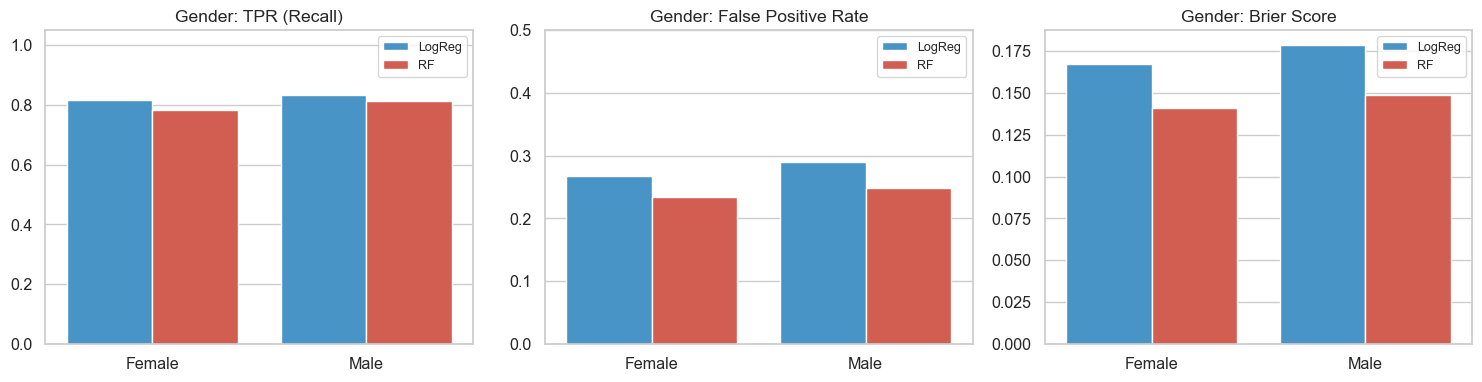

Saved gender and ethnicity fairness analysis.


In [37]:
# ===== GENDER FAIRNESS ANALYSIS =====
sex_map = {1: "Male", 2: "Female"}
sex_test_mapped = sex_test.map(sex_map)
valid_sex = sex_test_mapped.notna().values

print(f"Observations with valid SEX: {valid_sex.sum()} / {len(valid_sex)}")

yt_g = np.array(y_test)[valid_sex]
yp_g = np.array(y_pred)[valid_sex]
ypr_g = np.array(y_prob)[valid_sex]
yp_rf_g = np.array(y_pred_rf)[valid_sex]
ypr_rf_g = np.array(y_prob_rf)[valid_sex]
sex_labels = sex_test_mapped[valid_sex].values

gf_lr = build_group_metrics_df(yt_g, yp_g, ypr_g, sex_labels, protected_col="gender")
gf_rf = build_group_metrics_df(yt_g, yp_rf_g, ypr_rf_g, sex_labels, protected_col="gender")

print("=== Logistic Regression — Gender Fairness ===")
display(gf_lr[["gender", "n_samples", "positive_rate_true", "tpr", "fpr", "precision", "brier_score"]])
print("\n=== Random Forest — Gender Fairness ===")
display(gf_rf[["gender", "n_samples", "positive_rate_true", "tpr", "fpr", "precision", "brier_score"]])

# Intersectional analysis: Race x Gender
print("\n=== Intersectional: Race x Gender (LR) ===")
race_g = np.array(protected_test)[valid_sex]
inter_labels = np.array([f"{r} / {s}" for r, s in zip(race_g, sex_labels)])
inter_df = build_group_metrics_df(yt_g, yp_g, ypr_g, inter_labels, protected_col="race_gender")
inter_df = inter_df[inter_df["n_samples"] >= 10].copy()
display(inter_df[["race_gender", "n_samples", "positive_rate_true", "tpr", "fpr", "f1"]].round(4))

print("\n=== Hispanic Ethnicity Fairness (LR) ===")
hisp_map = {0: "Non-Hispanic", 1: "Hispanic"}
hisp_test_mapped = hisp_test.map(hisp_map)
valid_hisp = hisp_test_mapped.notna().values
yt_h = np.array(y_test)[valid_hisp]
yp_h = np.array(y_pred)[valid_hisp]
ypr_h = np.array(y_prob)[valid_hisp]
hisp_labels = hisp_test_mapped[valid_hisp].values
hf_lr = build_group_metrics_df(yt_h, yp_h, ypr_h, hisp_labels, protected_col="ethnicity")
display(hf_lr[["ethnicity", "n_samples", "positive_rate_true", "tpr", "fpr", "precision", "brier_score"]])

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, ylim in [(axes[0], "tpr", "TPR (Recall)", (0, 1.05)),
                              (axes[1], "fpr", "False Positive Rate", (0, 0.5)),
                              (axes[2], "brier_score", "Brier Score", None)]:
    plot_rows = []
    for _, r in gf_lr.iterrows():
        plot_rows.append({"Gender": r["gender"], "Value": r[col], "Model": "LogReg"})
    for _, r in gf_rf.iterrows():
        plot_rows.append({"Gender": r["gender"], "Value": r[col], "Model": "RF"})
    sns.barplot(data=pd.DataFrame(plot_rows), x="Gender", y="Value", hue="Model",
                ax=ax, palette=["#3498db", "#e74c3c"])
    ax.set_title(f"Gender: {title}"); ax.set_xlabel(""); ax.set_ylabel("")
    if ylim: ax.set_ylim(*ylim)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(output_dir / "gender_fairness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved gender and ethnicity fairness analysis.")

### Calibration Curves

To assess whether predicted probabilities are well-calibrated across racial groups, we plot calibration curves. A well-calibrated model should produce curves close to the diagonal. Deviations indicate that the model systematically over- or under-estimates risk for certain groups.

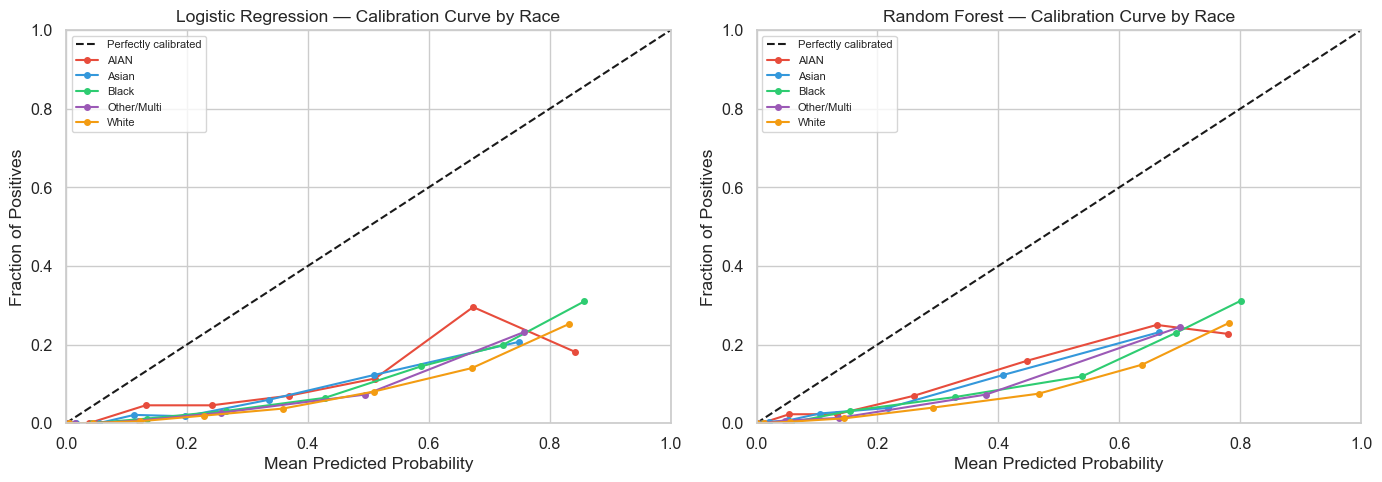

Saved calibration curves.


In [38]:
# ===== CALIBRATION CURVES BY RACE GROUP =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
groups = sorted(protected_test.unique())
colors = {"AIAN": "#e74c3c", "Asian": "#3498db", "Black": "#2ecc71",
          "Other/Multi": "#9b59b6", "White": "#f39c12"}

for ax, (probs, title) in [(axes[0], (y_prob, "Logistic Regression")),
                            (axes[1], (y_prob_rf, "Random Forest"))]:
    ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    prot_arr = np.array(protected_test)
    for g in groups:
        mask = prot_arr == g
        yt = np.array(y_test)[mask]
        yp = probs[mask]
        if len(yt) < 50:
            continue
        prob_true, prob_pred = calibration_curve(yt, yp, n_bins=8, strategy="quantile")
        ax.plot(prob_pred, prob_true, "o-", label=g, color=colors[g], markersize=4)
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"{title} — Calibration Curve by Race")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(output_dir / "calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved calibration curves.")

### Calibration Post-processing (Platt Scaling)

We now re-select the optimal threshold on the validation set after calibration, then evaluate on the test set. This provides a fair assessment of whether calibration actually improves classification utility and fairness.

In [39]:
# ===== CALIBRATION POST-PROCESSING =====
# Apply Platt scaling on the VALIDATION set, then evaluate on TEST set
cal_lr = CalibratedClassifierCV(log_reg_pipeline, method="sigmoid", cv="prefit")
cal_lr.fit(X_val, y_val)

y_prob_calibrated_test = cal_lr.predict_proba(X_test)[:, 1]
y_prob_calibrated_val = cal_lr.predict_proba(X_val)[:, 1]

# Using a hard 0.5 cutoff after Platt scaling produces near-zero recall because
# calibrated probabilities cluster near the true prevalence (~7%).
# Instead, sweep thresholds on validation and pick the one that maximises balanced accuracy.
cal_threshold_candidates = np.arange(0.03, 0.50, 0.01).round(2)
best_cal_threshold = 0.5
best_cal_bal_acc = 0.0

for t in cal_threshold_candidates:
    pred_val = (y_prob_calibrated_val >= t).astype(int)
    ba = balanced_accuracy_score(y_val, pred_val)
    if ba > best_cal_bal_acc:
        best_cal_bal_acc = ba
        best_cal_threshold = t

print(f"Calibrated model — optimal threshold from validation: {best_cal_threshold}")
print(f"  Val balanced_accuracy at this threshold: {best_cal_bal_acc:.4f}")

y_pred_calibrated = (y_prob_calibrated_test >= best_cal_threshold).astype(int)

print("\n=== Calibrated LR — Overall Metrics (threshold={:.2f}) ===".format(best_cal_threshold))
cal_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_calibrated),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_calibrated),
    "precision": precision_score(y_test, y_pred_calibrated, zero_division=0),
    "recall": recall_score(y_test, y_pred_calibrated, zero_division=0),
    "f1": f1_score(y_test, y_pred_calibrated, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_calibrated_test)
}
for k, v in cal_metrics.items():
    print(f"  {k}: {v:.4f}")

cal_group_df = build_group_metrics_df(
    y_test, y_pred_calibrated, y_prob_calibrated_test, protected_test
)

print("\n=== Calibrated LR — Group Metrics ===")
display(cal_group_df[["race_group", "n_samples", "tpr", "fpr", "brier_score"]].round(4))

# Compare Brier scores before/after calibration
uncal_brier = build_group_metrics_df(y_test, y_pred, y_prob, protected_test)
print("\n=== Brier Score Comparison (lower = better calibration) ===")
brier_compare = pd.DataFrame({
    "race_group": uncal_brier["race_group"],
    "brier_uncalibrated": uncal_brier["brier_score"],
    "brier_calibrated": cal_group_df["brier_score"],
    "improvement": uncal_brier["brier_score"] - cal_group_df["brier_score"]
})
display(brier_compare.round(4))

# Also compare classification metrics to check that calibration didn't destroy utility
print("\n=== Classification Utility: Uncalibrated vs Calibrated ===")
util_compare = pd.DataFrame([
    {"model": "LR uncalibrated (t=0.50)", **overall_metrics},
    {"model": f"LR calibrated (t={best_cal_threshold})", **cal_metrics}
]).round(4)
display(util_compare)
print("Note: Brier score measures probability calibration quality;")
print("classification metrics (recall, F1) measure screening utility.")
print("Calibration may improve one without improving the other.")

brier_compare.to_csv(output_dir / "calibration_comparison.csv", index=False)
print("\nSaved calibration comparison.")

Calibrated model — optimal threshold from validation: 0.08
  Val balanced_accuracy at this threshold: 0.7791

=== Calibrated LR — Overall Metrics (threshold=0.08) ===
  accuracy: 0.7216
  balanced_accuracy: 0.7725
  precision: 0.1764
  recall: 0.8316
  f1: 0.2910
  roc_auc: 0.8460

=== Calibrated LR — Group Metrics ===


,race_group,n_samples,tpr,fpr,brier_score
0,AIAN,351,0.7879,0.3050,0.0882
1,Asian,2280,0.7131,0.1733,0.0490
2,Black,4098,0.8795,0.3414,0.0797
3,Other/Multi,1207,0.8431,0.1618,0.0362
4,White,27419,0.8298,0.2935,0.0570



=== Brier Score Comparison (lower = better calibration) ===


,race_group,brier_uncalibrated,brier_calibrated,improvement
0,AIAN,0.1845,0.0882,0.0963
1,Asian,0.1166,0.0490,0.0676
2,Black,0.1970,0.0797,0.1173
3,Other/Multi,0.1010,0.0362,0.0648
4,White,0.1765,0.0570,0.1195



=== Classification Utility: Uncalibrated vs Calibrated ===


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,LR uncalibrated (t=0.50),0.7294,0.7731,0.1796,0.8238,0.295,0.846
1,LR calibrated (t=0.08),0.7216,0.7725,0.1764,0.8316,0.291,0.846


Note: Brier score measures probability calibration quality;
classification metrics (recall, F1) measure screening utility.
Calibration may improve one without improving the other.

Saved calibration comparison.


### Threshold-Based Post-processing Mitigation

To provide progress on bias mitigation for the logistic regression classifier, we evaluate several probability thresholds rather than relying only on the default threshold of 0.50. This serves as a simple post-processing mitigation strategy and makes the fairness--utility tradeoff explicit.

In [40]:
# Threshold sweep on VALIDATION set to avoid data leakage
y_prob_val = log_reg_pipeline.predict_proba(X_val)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_rows = []
threshold_group_results = {}

for thr in thresholds:
    y_pred_thr = (y_prob_val >= thr).astype(int)

    overall_thr = compute_overall_metrics_from_probs(y_val, y_prob_val, thr)

    group_thr_df = build_group_metrics_df(
        y_true=y_val,
        y_pred=y_pred_thr,
        y_prob=y_prob_val,
        protected_eval=protected_val,
        protected_col="race_group"
    )

    gap_thr = compute_gap_summary(group_thr_df)

    threshold_rows.append({
        **overall_thr,
        **gap_thr
    })

    threshold_group_results[thr] = group_thr_df.copy()

threshold_summary_df = pd.DataFrame(threshold_rows).round(4)
print("LR Threshold sweep (evaluated on VALIDATION set):")
display(threshold_summary_df)

threshold_summary_df.to_csv(output_dir / "logreg_threshold_summary.csv", index=False)
print("Saved: outputs/logreg_threshold_summary.csv")

LR Threshold sweep (evaluated on VALIDATION set):


,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,max_tpr_gap,max_fpr_gap,max_fnr_gap,max_pred_pos_gap
0,0.30,0.5816,0.7513,0.1358,0.9480,0.2375,0.8527,0.0437,0.2249,0.0437,0.2398
1,0.35,0.6195,0.7631,0.1454,0.9295,0.2514,0.8527,0.0686,0.2180,0.0686,0.2350
2,0.40,0.6583,0.7713,0.1562,0.9023,0.2663,0.8527,0.0934,0.2005,0.0934,0.2200
3,0.45,0.6946,0.7758,0.1678,0.8699,0.2814,0.8527,0.1167,0.1933,0.1167,0.2123
4,0.50,0.7305,0.7800,0.1822,0.8374,0.2993,0.8527,0.1841,0.1832,0.1841,0.2057
5,0.55,0.7644,0.7734,0.1962,0.7840,0.3138,0.8527,0.2006,0.1738,0.2006,0.1971
6,0.60,0.7941,0.7665,0.2120,0.7346,0.3290,0.8527,0.1722,0.1630,0.1722,0.1853


Saved: outputs/logreg_threshold_summary.csv


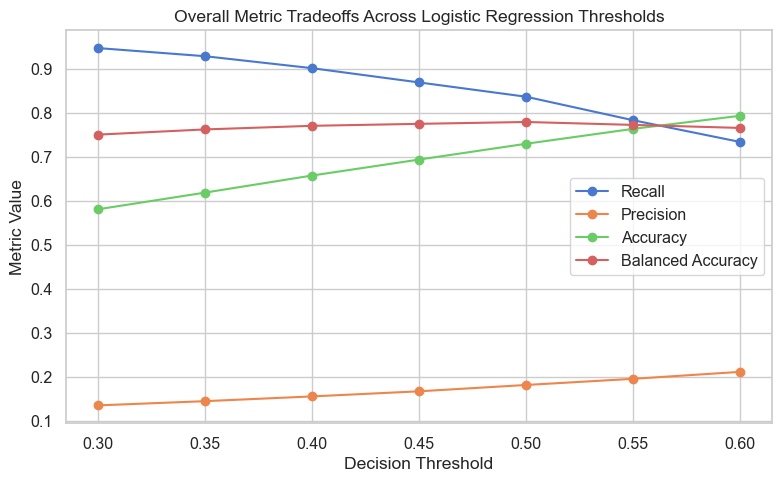

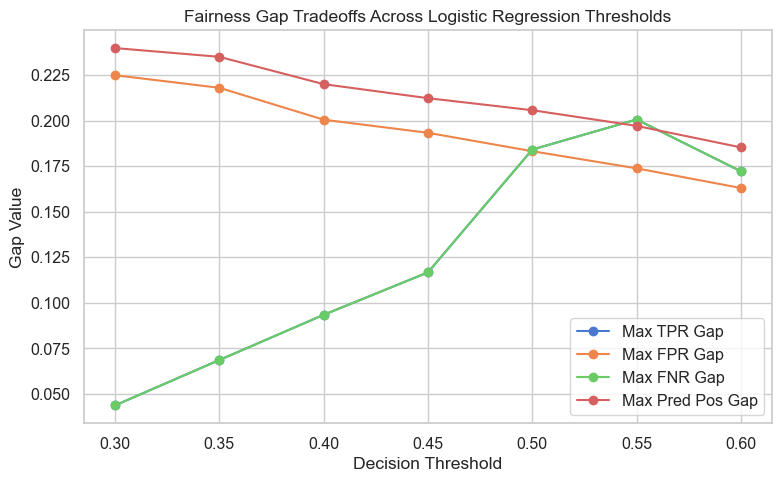

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["recall"], marker="o", label="Recall")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["precision"], marker="o", label="Precision")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["balanced_accuracy"], marker="o", label="Balanced Accuracy")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Overall Metric Tradeoffs Across Logistic Regression Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_tpr_gap"], marker="o", label="Max TPR Gap")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_fpr_gap"], marker="o", label="Max FPR Gap")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_fnr_gap"], marker="o", label="Max FNR Gap")
plt.plot(threshold_summary_df["threshold"], threshold_summary_df["max_pred_pos_gap"], marker="o", label="Max Pred Pos Gap")
plt.xlabel("Decision Threshold")
plt.ylabel("Gap Value")
plt.title("Fairness Gap Tradeoffs Across Logistic Regression Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

### Global Threshold Mitigation (Auto-selected)

Rather than manually choosing a threshold, we automatically select the threshold from the validation sweep that minimizes the maximum FPR gap while maintaining recall ≥ 0.70. This threshold is then applied to the held-out test set for unbiased evaluation.

In [42]:
# Auto-select threshold: minimize max_fpr_gap with recall >= 0.70
candidates = threshold_summary_df[threshold_summary_df["recall"] >= 0.70].copy()
if len(candidates) > 0:
    best_row = candidates.sort_values("max_fpr_gap").iloc[0]
    chosen_threshold = float(best_row["threshold"])
    print(f"Auto-selected threshold (from validation sweep): {chosen_threshold}")
    print(f"  Val recall at this threshold: {best_row['recall']:.4f}")
    print(f"  Val max_fpr_gap: {best_row['max_fpr_gap']:.4f}")
else:
    chosen_threshold = 0.50
    print(f"No threshold met recall >= 0.70. Falling back to default: {chosen_threshold}")

print("\nEvaluating on held-out TEST set:\n")

y_pred_mitigated = (y_prob >= chosen_threshold).astype(int)

overall_metrics_mitigated = compute_overall_metrics_from_probs(y_test, y_prob, chosen_threshold)

group_metrics_mitigated_df = build_group_metrics_df(
    y_true=y_test,
    y_pred=y_pred_mitigated,
    y_prob=y_prob,
    protected_eval=protected_test,
    protected_col="race_group"
)

mitigation_gap_summary = compute_gap_summary(group_metrics_mitigated_df)

mitigation_summary_df = pd.DataFrame([
    {"model": "logreg_balanced_default_0.5", **overall_metrics, **compute_gap_summary(group_metrics_logreg_df)},
    {"model": f"logreg_postprocessed_thr_{chosen_threshold}", **overall_metrics_mitigated, **mitigation_gap_summary}
]).round(4)

display(mitigation_summary_df)

mitigation_summary_df.to_csv(output_dir / "logreg_postprocessing_mitigation_summary.csv", index=False)
group_metrics_mitigated_df.to_csv(output_dir / "logreg_postprocessing_group_metrics.csv", index=False)
print("Saved post-processing mitigation results.")

Auto-selected threshold (from validation sweep): 0.6
  Val recall at this threshold: 0.7346
  Val max_fpr_gap: 0.1630

Evaluating on held-out TEST set:



,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,max_tpr_gap,max_fpr_gap,max_fnr_gap,max_pred_pos_gap,threshold
0,logreg_balanced_default_0.5,0.7294,0.7731,0.1796,0.8238,0.2950,0.846,0.1884,0.1764,0.1884,0.1999,NaN
1,logreg_postprocessed_thr_0.6,0.7917,0.7558,0.2064,0.7143,0.3203,0.846,0.2646,0.1468,0.2646,0.1740,0.6


Saved post-processing mitigation results.


### Random Forest Threshold Sweep

To extend the threshold-based mitigation analysis beyond logistic regression, we apply the same threshold sweep to the random forest model on the **validation set**, consistent with the LR analysis above.

RF Threshold sweep (evaluated on VALIDATION set):


,threshold,accuracy,balanced_accuracy,precision,recall,f1,max_tpr_gap,max_fpr_gap,max_ppr_gap
0,0.25,0.6078,0.7670,0.1440,0.9516,0.2501,0.0446,0.2322,0.2475
1,0.30,0.6423,0.7760,0.1535,0.9311,0.2635,0.0910,0.2243,0.2426
2,0.35,0.6735,0.7847,0.1638,0.9136,0.2778,0.1088,0.2161,0.2368
3,0.40,0.7011,0.7878,0.1733,0.8884,0.2900,0.1691,0.1980,0.2204
4,0.45,0.7321,0.7881,0.1853,0.8529,0.3044,0.1854,0.1910,0.2120
5,0.50,0.7642,0.7870,0.2005,0.8133,0.3217,0.1832,0.1801,0.2028
6,0.55,0.7917,0.7798,0.2150,0.7659,0.3358,0.2202,0.1723,0.1973
7,0.60,0.8177,0.7628,0.2292,0.6991,0.3452,0.2448,0.1546,0.1806


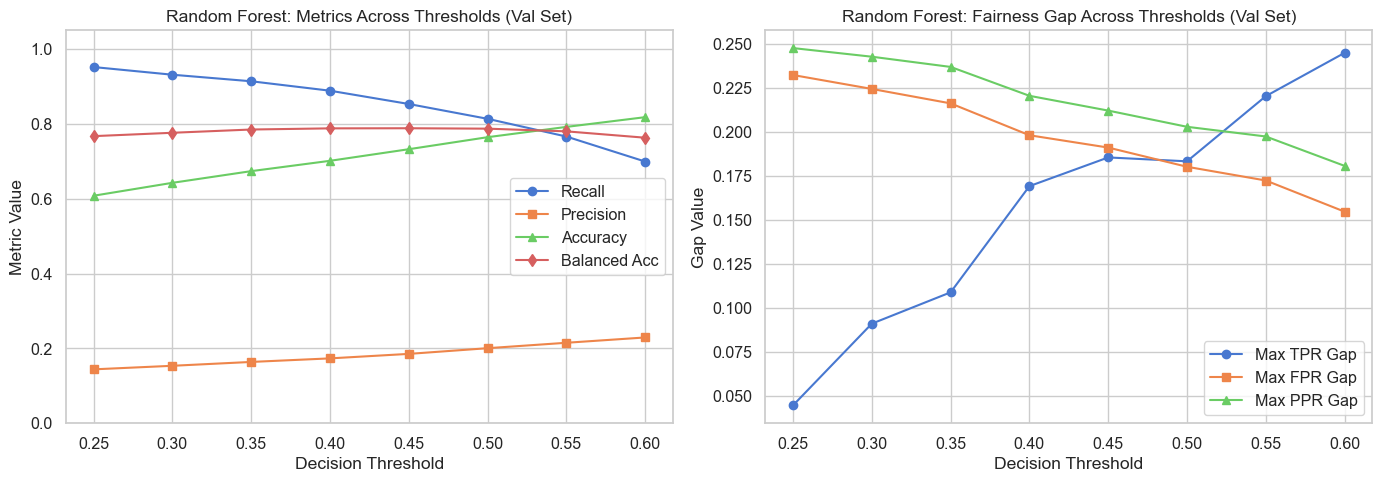

Saved RF threshold sweep files.


In [43]:
# ===== RANDOM FOREST THRESHOLD SWEEP (VALIDATION SET) =====
y_prob_rf_val = rf_pipeline.predict_proba(X_val)[:, 1]

thresholds_rf = np.arange(0.25, 0.65, 0.05).round(2)
rf_threshold_rows = []

for t in thresholds_rf:
    yp = (y_prob_rf_val >= t).astype(int)
    yt = np.array(y_val)
    prot = np.array(protected_val)
    row = {
        "threshold": t,
        "accuracy": accuracy_score(yt, yp),
        "balanced_accuracy": balanced_accuracy_score(yt, yp),
        "precision": precision_score(yt, yp, zero_division=0),
        "recall": recall_score(yt, yp, zero_division=0),
        "f1": f1_score(yt, yp, zero_division=0),
    }
    group_tprs, group_fprs, group_pprs = [], [], []
    for g in sorted(set(prot)):
        mask = prot == g
        if mask.sum() == 0: continue
        tn, fp, fn, tp = confusion_matrix(yt[mask], yp[mask], labels=[0, 1]).ravel()
        group_tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        group_fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        group_pprs.append((tp + fp) / mask.sum())
    row["max_tpr_gap"] = max(group_tprs) - min(group_tprs)
    row["max_fpr_gap"] = max(group_fprs) - min(group_fprs)
    row["max_ppr_gap"] = max(group_pprs) - min(group_pprs)
    rf_threshold_rows.append(row)

rf_thresh_df = pd.DataFrame(rf_threshold_rows).round(4)
print("RF Threshold sweep (evaluated on VALIDATION set):")
display(rf_thresh_df)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rf_thresh_df["threshold"], rf_thresh_df["recall"], "o-", label="Recall")
axes[0].plot(rf_thresh_df["threshold"], rf_thresh_df["precision"], "s-", label="Precision")
axes[0].plot(rf_thresh_df["threshold"], rf_thresh_df["accuracy"], "^-", label="Accuracy")
axes[0].plot(rf_thresh_df["threshold"], rf_thresh_df["balanced_accuracy"], "d-", label="Balanced Acc")
axes[0].set_xlabel("Decision Threshold"); axes[0].set_ylabel("Metric Value")
axes[0].set_title("Random Forest: Metrics Across Thresholds (Val Set)")
axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].plot(rf_thresh_df["threshold"], rf_thresh_df["max_tpr_gap"], "o-", label="Max TPR Gap")
axes[1].plot(rf_thresh_df["threshold"], rf_thresh_df["max_fpr_gap"], "s-", label="Max FPR Gap")
axes[1].plot(rf_thresh_df["threshold"], rf_thresh_df["max_ppr_gap"], "^-", label="Max PPR Gap")
axes[1].set_xlabel("Decision Threshold"); axes[1].set_ylabel("Gap Value")
axes[1].set_title("Random Forest: Fairness Gap Across Thresholds (Val Set)")
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir / "rf_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

rf_thresh_df.to_csv(output_dir / "rf_threshold_sweep.csv", index=False)
print("Saved RF threshold sweep files.")

### Debiasing Methods Comparison

We compare five approaches:
1. LR baseline (default threshold 0.5)
2. Global threshold adjustment (auto-selected from validation sweep)
3. Reweighting as a pre-processing method (with weight clipping)
4. **TPR Parity post-processing** with per-group thresholds targeting TPR ≈ 0.80
5. **TPR+FPR Penalty post-processing** with per-group thresholds that balance TPR targeting and FPR minimisation

Reweighting stats: min=0.14, max=10.00, mean=0.75, std=1.61
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Reweighted LR best C: {'classifier__C': 10.0}
Best CV balanced_accuracy: 0.7525
TPR+FPR Penalty per-group thresholds: {'AIAN': 0.47, 'Asian': 0.445, 'Black': 0.615, 'Other/Multi': 0.605, 'White': 0.535}
TPR-Parity per-group thresholds: {'AIAN': 0.44, 'Asian': 0.43, 'Black': 0.6, 'Other/Multi': 0.58, 'White': 0.53}


,model,accuracy,balanced_acc,precision,recall,f1,max_tpr_gap,max_fpr_gap,max_ppr_gap
0,LR Baseline (t=0.50),0.7294,0.7731,0.1796,0.8238,0.2950,0.1884,0.1764,0.1999
1,LR Global Thr (t=0.6),0.7917,0.7558,0.2064,0.7143,0.3203,0.2646,0.1467,0.1740
2,LR Reweighting (balanced+tuned),0.7952,0.7434,0.2041,0.6834,0.3143,0.2789,0.1498,0.1729
3,LR TPR-Parity Post-proc,0.7501,0.7669,0.1868,0.7863,0.3019,0.0699,0.2157,0.2327
4,LR TPR+FPR Penalty Post-proc,0.7551,0.7658,0.1888,0.7781,0.3039,0.0656,0.2063,0.2248


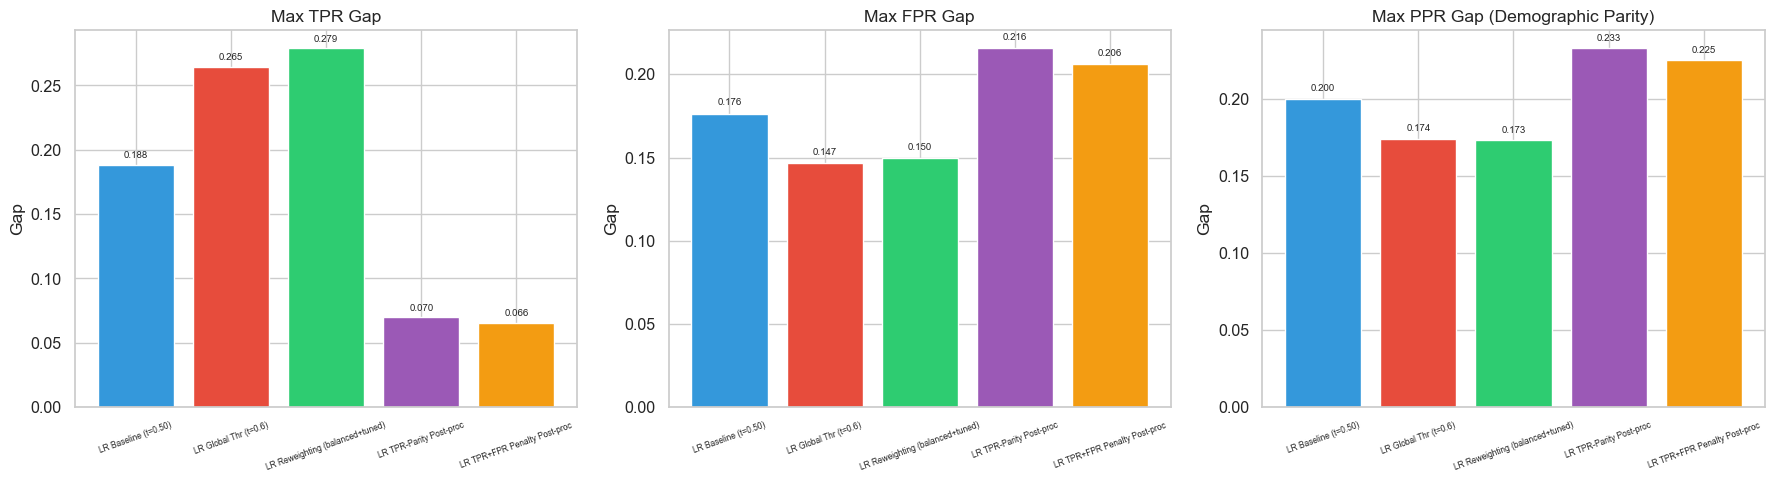

Saved debiasing comparison files.


In [44]:
# ===== DEBIASING METHODS COMPARISON =====

# Method 1: Reweighting (pre-processing)
sample_weights = compute_reweights(y_train, protected_train, max_weight=10.0)

param_grid_rw = {"classifier__C": [0.001, 0.01, 0.1, 1.0, 10.0]}
rw_base_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Custom scorer that passes sample_weight during CV fitting
# Note: GridSearchCV will use sample_weights during fit via fit_params
from sklearn.model_selection import StratifiedKFold

grid_search_rw = GridSearchCV(
    rw_base_pipeline,
    param_grid=param_grid_rw,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)
grid_search_rw.fit(X_train, y_train, classifier__sample_weight=sample_weights)

lr_reweighted = grid_search_rw.best_estimator_
print(f"Reweighted LR best C: {grid_search_rw.best_params_}")
print(f"Best CV balanced_accuracy: {grid_search_rw.best_score_:.4f}")

y_pred_rw = lr_reweighted.predict(X_test)
y_prob_rw = lr_reweighted.predict_proba(X_test)[:, 1]

# Method 2: TPR+FPR Penalty post-processing
# implementation (Hardt et al. 2016). True EqOdds requires joint optimisation
# across groups via linear programming to simultaneously equalise TPR and FPR.
# This method independently searches per-group thresholds using a heuristic objective.
y_prob_val = log_reg_pipeline.predict_proba(X_val)[:, 1]

def find_tpr_fpr_penalty_thresholds(y_true, y_prob, protected, target_tpr=0.80):
    """Find per-group thresholds using heuristic: minimise |TPR-target| + 0.5*FPR.
    
    NOTE: This is NOT Equalized Odds (Hardt et al. 2016). True EqOdds requires
    jointly solving a linear program across groups. This heuristic independently
    optimises each group, so cross-group equality is not guaranteed.
    """
    y_true, y_prob, protected = map(np.array, [y_true, y_prob, protected])
    groups = sorted(set(protected))
    
    candidate_thresholds = {}
    for g in groups:
        mask = protected == g
        yt, yp = y_true[mask], y_prob[mask]
        best_t, best_score = 0.5, 999
        for t in np.arange(0.05, 0.95, 0.005):
            pred = (yp >= t).astype(int)
            tpr = pred[yt == 1].mean() if (yt == 1).sum() > 0 else 0
            fpr = pred[yt == 0].mean() if (yt == 0).sum() > 0 else 0
            score = abs(tpr - target_tpr) + 0.5 * fpr
            if score < best_score:
                best_score = score
                best_t = t
        candidate_thresholds[g] = round(best_t, 3)
    
    return candidate_thresholds

def find_tpr_parity_thresholds(y_true, y_prob, protected, target_tpr=0.80):
    """Per-group thresholds targeting TPR parity only."""
    y_true, y_prob, protected = map(np.array, [y_true, y_prob, protected])
    groups = sorted(set(protected))
    thresholds = {}
    for g in groups:
        mask = protected == g
        yt, yp = y_true[mask], y_prob[mask]
        best_t, best_diff = 0.5, 999
        for t in np.arange(0.05, 0.95, 0.01):
            pred = (yp >= t).astype(int)
            tpr = pred[yt == 1].mean() if (yt == 1).sum() > 0 else 0
            diff = abs(tpr - target_tpr)
            if diff < best_diff:
                best_diff = diff
                best_t = t
        thresholds[g] = round(best_t, 2)
    return thresholds

# Thresholds tuned on VALIDATION set
penalty_thresholds = find_tpr_fpr_penalty_thresholds(y_val, y_prob_val, protected_val, target_tpr=0.80)
tpr_thresholds = find_tpr_parity_thresholds(y_val, y_prob_val, protected_val, target_tpr=0.80)
print("TPR+FPR Penalty per-group thresholds:", penalty_thresholds)
print("TPR-Parity per-group thresholds:", tpr_thresholds)

# Apply TPR+FPR Penalty thresholds to TEST set
y_pred_penalty = np.zeros(len(y_test), dtype=int)
for g, t in penalty_thresholds.items():
    mask = np.array(protected_test) == g
    y_pred_penalty[mask] = (y_prob[mask] >= t).astype(int)

# Apply TPR-Parity thresholds to TEST set
y_pred_tpr = np.zeros(len(y_test), dtype=int)
for g, t in tpr_thresholds.items():
    mask = np.array(protected_test) == g
    y_pred_tpr[mask] = (y_prob[mask] >= t).astype(int)

# Compare all methods
def eval_debiasing(y_true, y_pred, protected, name):
    y_true, y_pred, protected = map(np.array, [y_true, y_pred, protected])
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    tprs, fprs, pprs = [], [], []
    for g in sorted(set(protected)):
        mask = protected == g
        tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask], labels=[0, 1]).ravel()
        tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        pprs.append((tp + fp) / mask.sum())
    row["max_tpr_gap"] = round(max(tprs) - min(tprs), 4)
    row["max_fpr_gap"] = round(max(fprs) - min(fprs), 4)
    row["max_ppr_gap"] = round(max(pprs) - min(pprs), 4)
    return row

debiasing_compare = pd.DataFrame([
    eval_debiasing(y_test, y_pred, protected_test, "LR Baseline (t=0.50)"),
    eval_debiasing(y_test, (y_prob >= chosen_threshold).astype(int), protected_test, f"LR Global Thr (t={chosen_threshold})"),
    eval_debiasing(y_test, y_pred_rw, protected_test, "LR Reweighting (balanced+tuned)"),
    eval_debiasing(y_test, y_pred_tpr, protected_test, "LR TPR-Parity Post-proc"),
    eval_debiasing(y_test, y_pred_penalty, protected_test, "LR TPR+FPR Penalty Post-proc"),
]).round(4)

display(debiasing_compare)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = debiasing_compare["model"].values
x = np.arange(len(models))
colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12"]

for ax, col, title in [(axes[0], "max_tpr_gap", "Max TPR Gap"),
                        (axes[1], "max_fpr_gap", "Max FPR Gap"),
                        (axes[2], "max_ppr_gap", "Max PPR Gap (Demographic Parity)")]:
    bars = ax.bar(x, debiasing_compare[col], color=colors[:len(x)])
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=6, rotation=20)
    ax.set_title(title)
    ax.set_ylabel("Gap")
    for b, v in zip(bars, debiasing_compare[col]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig(output_dir / "debiasing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

debiasing_compare.to_csv(output_dir / "debiasing_comparison.csv", index=False)
print("Saved debiasing comparison files.")

In [45]:
comparison_df_all.to_csv(output_dir / "model_comparison_overall_metrics.csv", index=False)

# Also persist the debiasing comparison (was only saved inside Cell 75; add here for completeness)
if "debiasing_compare" in dir():
    debiasing_compare.to_csv(output_dir / "debiasing_comparison_final.csv", index=False)
    print("Saved: outputs_2/debiasing_comparison_final.csv")

print("All outputs saved to outputs_2/")

Saved: outputs_2/debiasing_comparison_final.csv
All outputs saved to outputs_2/


## Key Findings

1. **Feature Importance**: AGE, WEIGHT, and self-reported HEALTH are the strongest predictors in both models. Socioeconomic variables such as POVERTY, EDUC, and EMPSTAT also contribute substantially. Because these factors are correlated with race, they may act as indirect pathways through which subgroup disparities emerge.

2. **Subgroup Disparities**: Both logistic regression and random forest show non-trivial disparities across racial groups in TPR, FPR, FNR, and predicted positive rates. These disparities indicate that model performance is not evenly distributed across groups, even when overall performance appears acceptable.

3. **Small-Sample Instability**: Metrics for smaller groups, especially AIAN and Other/Multi, are substantially less stable than those for larger groups such as White. Bootstrap confidence intervals suggest that subgroup estimates for small groups should be interpreted cautiously.

4. **Debiasing Trade-offs**: Global thresholding, reweighting, and group-specific post-processing lead to different fairness–utility trade-offs. Some methods reduce particular disparities, such as FPR gaps, while worsening others, such as TPR gaps. No single method achieves uniform improvement across all fairness and utility metrics.

5. **Socioeconomic Confounding**: AIAN and Black groups show higher observed diabetes rates together with stronger indicators of socioeconomic disadvantage and healthcare access barriers. This suggests that the models may be learning patterns associated not only with disease risk, but also with structural inequality.

6. **Label Bias**: The target variable reflects diagnosed Type 2 diabetes rather than true underlying prevalence. Groups with lower healthcare access may be underdiagnosed, which means that part of the observed disparity may originate in the label itself rather than only in the model.

7. **Calibration**: Calibration methods such as Platt scaling can improve probability calibration and reduce some cross-group Brier score disparities. However, better calibration does not automatically translate into better classification performance or improved fairness under thresholded decisions.

8. **Low Precision / Screening Interpretation**: Although several models achieve moderate-to-high recall, precision remains low because the positive class is relatively rare. These models are therefore better interpreted as screening-oriented tools rather than diagnostic systems, and their false-positive burden should be considered carefully in any healthcare setting.

9. **Data Processing Sensitivity**: Fairness results are sensitive to preprocessing choices, including the treatment of special codes, missing values, and subgroup definitions. Careful data cleaning is therefore a core part of fairness analysis rather than a purely technical preprocessing step.

10. **Limitations**:
   - This analysis does not incorporate NHIS survey weights, so subgroup rates and disparities may not be nationally representative.
   - NHIS household clustering is not explicitly modeled, so uncertainty may be underestimated.
   - Missing data are handled through pipeline imputation, which may introduce bias if missingness is non-random across groups.
   - Only logistic regression and random forest are evaluated; other model families may yield different fairness–utility trade-offs.
   - The data span 2020–2024, including the COVID-19 period, so temporal confounding may remain.
   - A full Equalized Odds implementation was not attempted; the group-specific threshold methods used here are heuristic and do not guarantee simultaneous equalization of TPR and FPR.